# Sensor Data Exploration
This notebook provides a concise workflow for exploring multiple sensor datasets with pandas. It covers:

- Loading sensor files (CSV/JSON) and combining them into a single DataFrame.
- Parsing and aligning timestamps, setting a datetime index.
- Cleaning steps: handling missing values, duplicates, outliers, and unit/column harmonization.
- Quick descriptive statistics, group summaries by sensor/type, and checks for data quality.
- Time-series operations: resampling, rolling aggregates, and interpolation to common frequencies.
- Visualizations: time series plots, distributions, correlation matrices, and simple anomaly detection.
- Exporting cleaned datasets and prepared features for downstream modeling or reporting.

Expected inputs: one or more files containing timestamp, sensor_id (or similar), and measurement columns.  
Outputs: a cleaned, merged DataFrame, summary tables, and plots to guide further analysis.

In [153]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters, EfficientFCParameters
from reservoirpy.nodes import Reservoir

#Declare the path for datasets
data_path = '../data'

In [30]:
#Display all files
files = os.listdir(f"{data_path}/raw/")
files

['2026_06_08_glass_01.csv',
 '2026_06_08_glass_03.csv',
 '2026_06_08_glass_02.csv',
 '2026_06_08_aluminum_02.csv',
 '2026_06_08_steel_03.csv',
 '2026_06_08_pdms_01.csv',
 '2026_06_08_steel_02.csv',
 '2026_06_08_aluminum_03.csv',
 '2026_06_08_aluminum_01.csv',
 '2026_06_08_pdms_02.csv',
 '2026_06_08_pdms_03.csv',
 '2026_06_08_steel_01.csv',
 '2026_06_08_corkboard_01.csv',
 '2026_06_08_corkboard_02.csv',
 '2026_06_08_corkboard_03.csv']

In [31]:
al1 = pd.read_csv(f"{data_path}/raw/2026_06_08_aluminum_01.csv").dropna()
al1.head()

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,aluminum,1.0,0.00939,0.00066,0.000699
1,2.0,aluminum,1.0,0.10066,0.00066,0.000699
2,3.0,aluminum,1.0,0.20070,0.00066,0.000699
3,4.0,aluminum,1.0,0.30070,0.00066,0.000699
4,5.0,aluminum,1.0,0.40070,0.00066,0.000699


In [32]:
al1.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      148 non-null    float64
 1   Sample     148 non-null    str    
 2   Trial      148 non-null    float64
 3   Time       148 non-null    float64
 4   Primary    148 non-null    float64
 5   Secondary  148 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.1 KB


#  Plot the sensor data

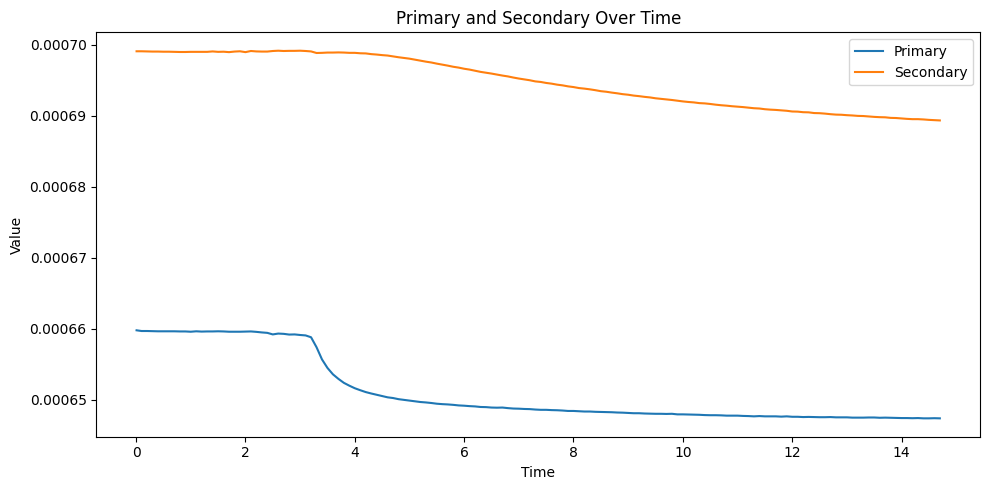

In [33]:
# Plotting Primary and Secondary Readings Over Time
plt.figure(figsize=(10, 5))
plt.plot(al1['Time'], al1['Primary'], label='Primary')
plt.plot(al1['Time'], al1['Secondary'], label='Secondary')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Primary and Secondary Over Time')
plt.legend()
plt.tight_layout()
plt.show()

Combine all sensor data

In [34]:
data = pd.DataFrame()
for f in files:
    df = pd.read_csv(f"{data_path}/raw/{f}").dropna()
    data = pd.concat([data, df], ignore_index=True)
data['Sample'] = data['Sample'].str.lower()
data

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,glass,1.0,0.00938,0.000660,0.000699
1,2.0,glass,1.0,0.10067,0.000660,0.000699
2,3.0,glass,1.0,0.20067,0.000660,0.000699
3,4.0,glass,1.0,0.30067,0.000660,0.000699
4,5.0,glass,1.0,0.40067,0.000660,0.000699
...,...,...,...,...,...,...
2864,182.0,corkboard,3.0,18.10066,0.000658,0.000697
2865,183.0,corkboard,3.0,18.20066,0.000658,0.000697
2866,184.0,corkboard,3.0,18.30066,0.000658,0.000697
2867,185.0,corkboard,3.0,18.40066,0.000658,0.000697


In [35]:
data['Sample'].value_counts()

Sample
corkboard    683
glass        675
pdms         550
steel        497
aluminum     464
Name: count, dtype: int64

In [36]:
materials = list(data['Sample'].unique())
materials

['glass', 'aluminum', 'steel', 'pdms', 'corkboard']

In [37]:
data.groupby('Sample').describe().T

Sample             aluminum     corkboard       glass        pdms       steel
index     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean    78.269397  1.264480e+02  113.045926   94.298182   87.004024
          std     45.468412  8.567507e+01   65.078628   56.418988   54.103545
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%     39.000000  5.750000e+01   57.000000   46.250000   42.000000
          50%     78.000000  1.140000e+02  113.000000   92.000000   83.000000
          75%    116.250000  1.740000e+02  169.000000  138.000000  125.000000
          max    171.000000  3.320000e+02  230.000000  215.000000  213.000000
Trial     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     2.049569  1.786237e+00    2.005926    2.074545    1.832998
          std      0.828567  8.448487e-01    0.822510    0.777582    0.814608
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          50%      2.000000  2.000000e+00    2.000000    2.000000    2.000000
          75%      3.000000  3.000000e+00    3.000000    3.000000    3.000000
          max      3.000000  3.000000e+00    3.000000    3.000000    3.000000
Time      count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     7.727677  1.254552e+01   11.205316    9.330547    8.601137
          std      4.546746  8.567452e+00    6.507796    5.641821    5.410272
          min      0.009320  9.260000e-03    0.009240    0.009270    0.009290
          25%      3.800700  5.650680e+00    5.600665    4.525670    4.100700
          50%      7.700660  1.130070e+01   11.200660    9.100680    8.200700
          75%     11.525690  1.730068e+01   16.800705   13.700692   12.400670
          max     17.000660  3.310070e+01   22.900700   21.400700   21.200660
Primary   count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000651  6.584616e-04    0.000655    0.000656    0.000652
          std      0.000005  8.365109e-07    0.000005    0.000002    0.000005
          min      0.000647  6.572000e-04    0.000649    0.000653    0.000648
          25%      0.000648  6.579200e-04    0.000650    0.000654    0.000649
          50%      0.000649  6.582000e-04    0.000653    0.000655    0.000649
          75%      0.000658  6.592500e-04    0.000660    0.000657    0.000659
          max      0.000660  6.603200e-04    0.000660    0.000660    0.000661
Secondary count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000694  6.980648e-04    0.000696    0.000697    0.000695
          std      0.000003  7.685482e-07    0.000003    0.000002    0.000004
          min      0.000689  6.966000e-04    0.000690    0.000693    0.000689
          25%      0.000691  6.974800e-04    0.000693    0.000695    0.000691
          50%      0.000694  6.980400e-04    0.000698    0.000696    0.000695
          75%      0.000697  6.987900e-04    0.000699    0.000699    0.000699
          max      0.000699  6.994200e-04    0.000700    0.000699    0.000700

## Plot all materials

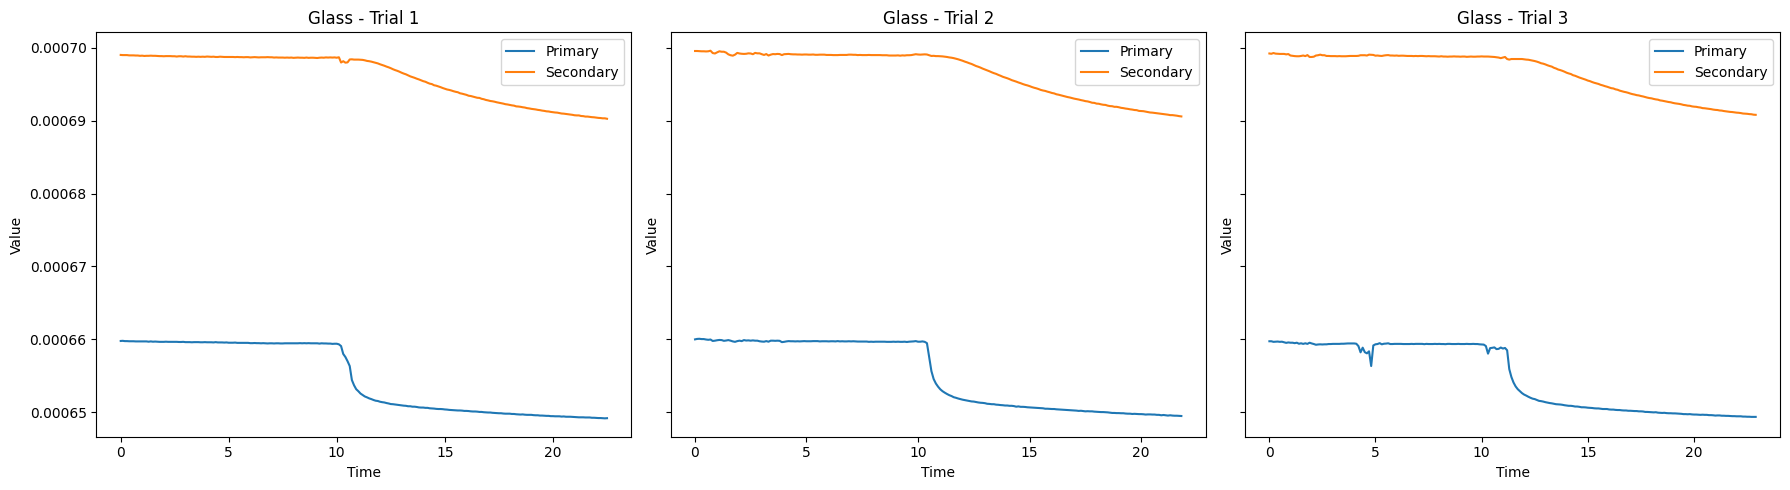

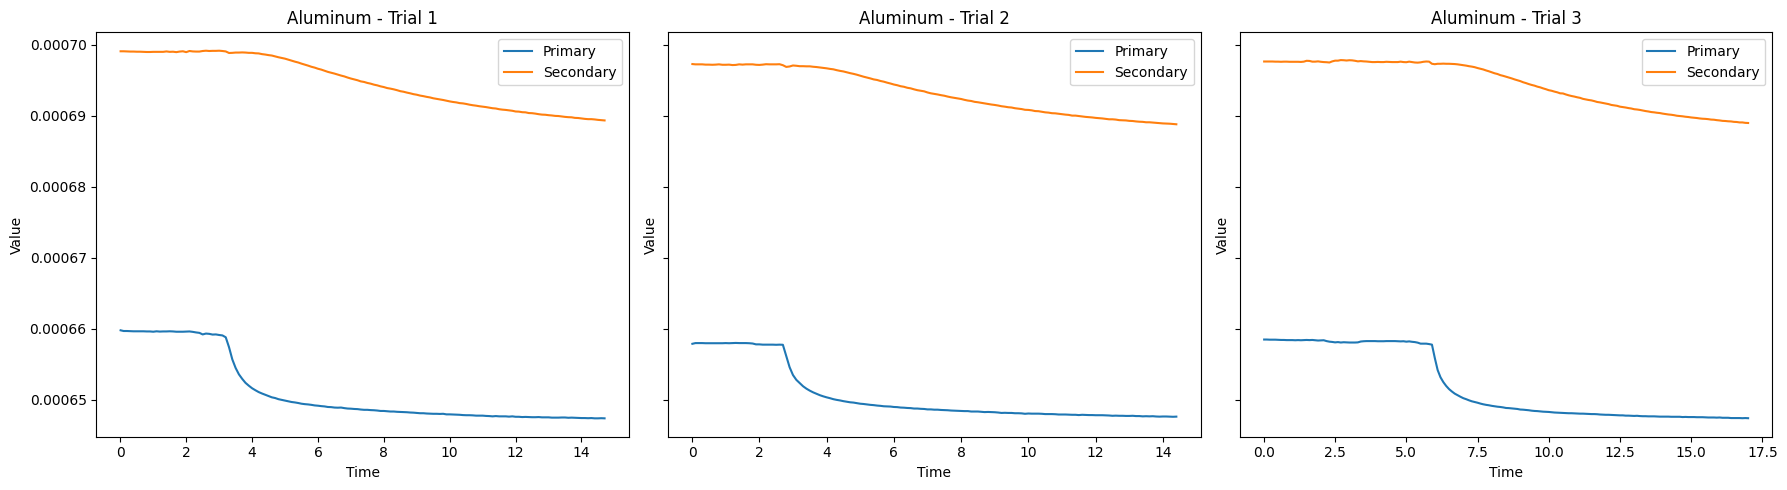

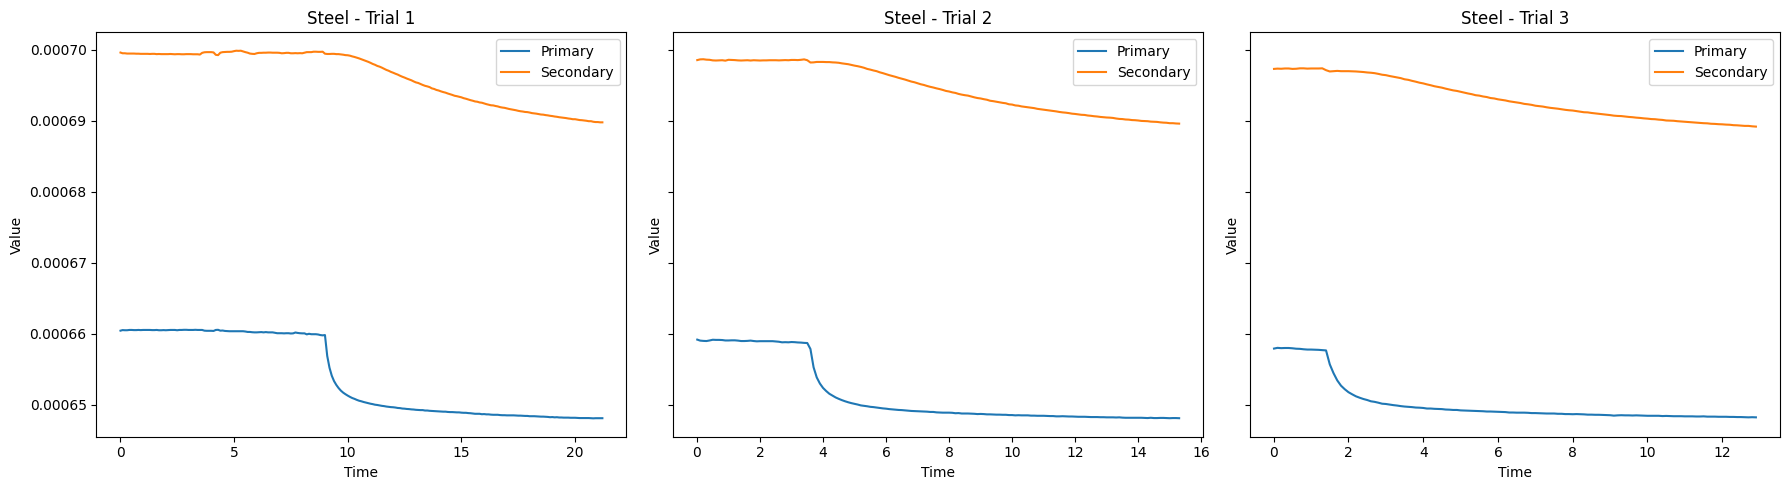

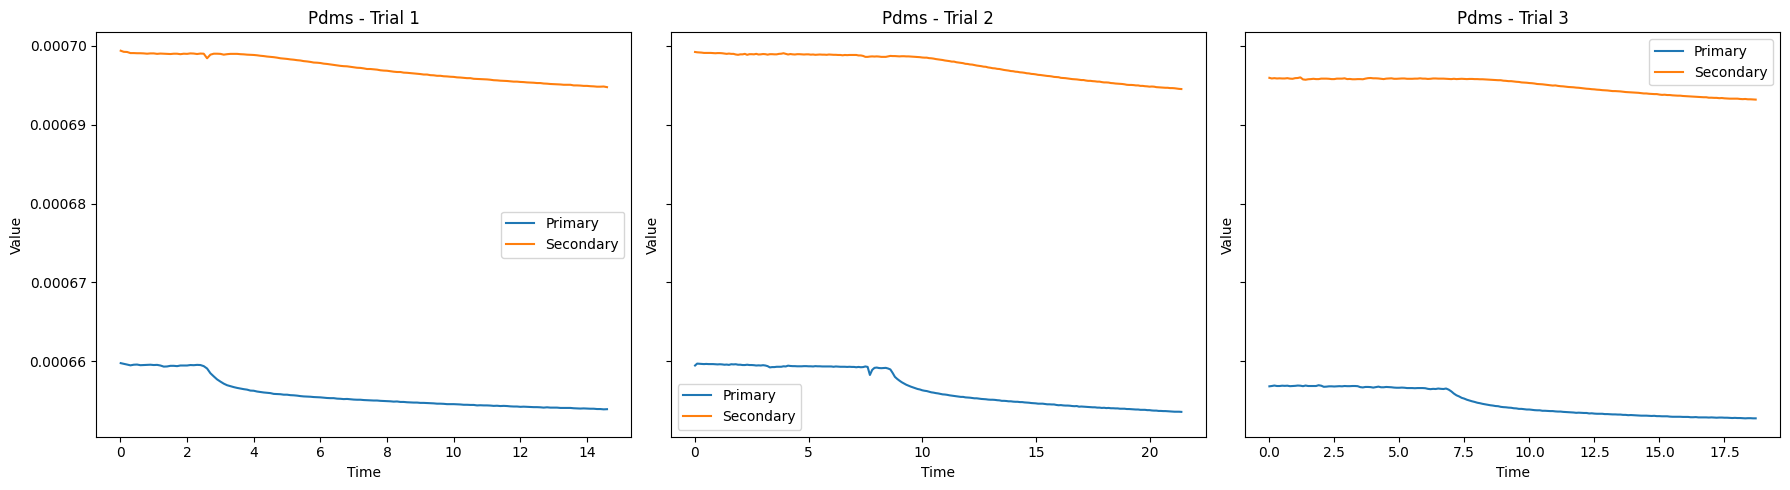

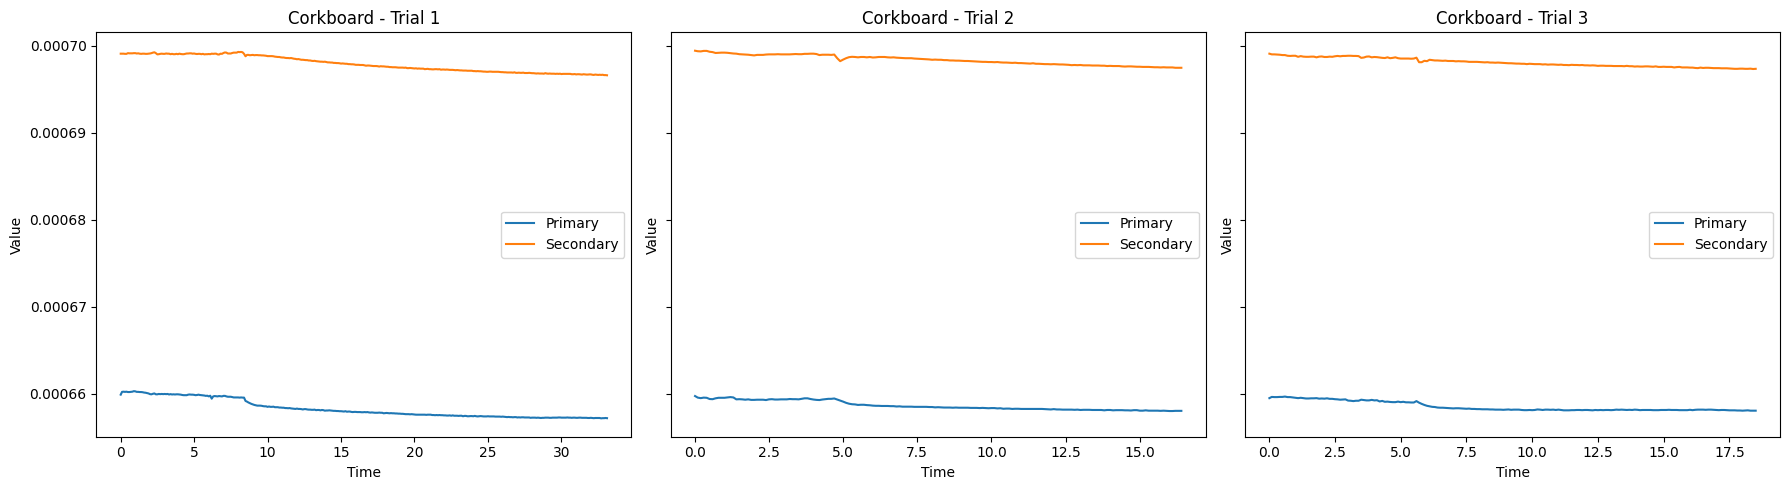

In [38]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [39]:
data.head()

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,glass,1.0,0.00938,0.00066,0.000699
1,2.0,glass,1.0,0.10067,0.00066,0.000699
2,3.0,glass,1.0,0.20067,0.00066,0.000699
3,4.0,glass,1.0,0.30067,0.00066,0.000699
4,5.0,glass,1.0,0.40067,0.00066,0.000699


## Plot Primary-Secondary Differnce

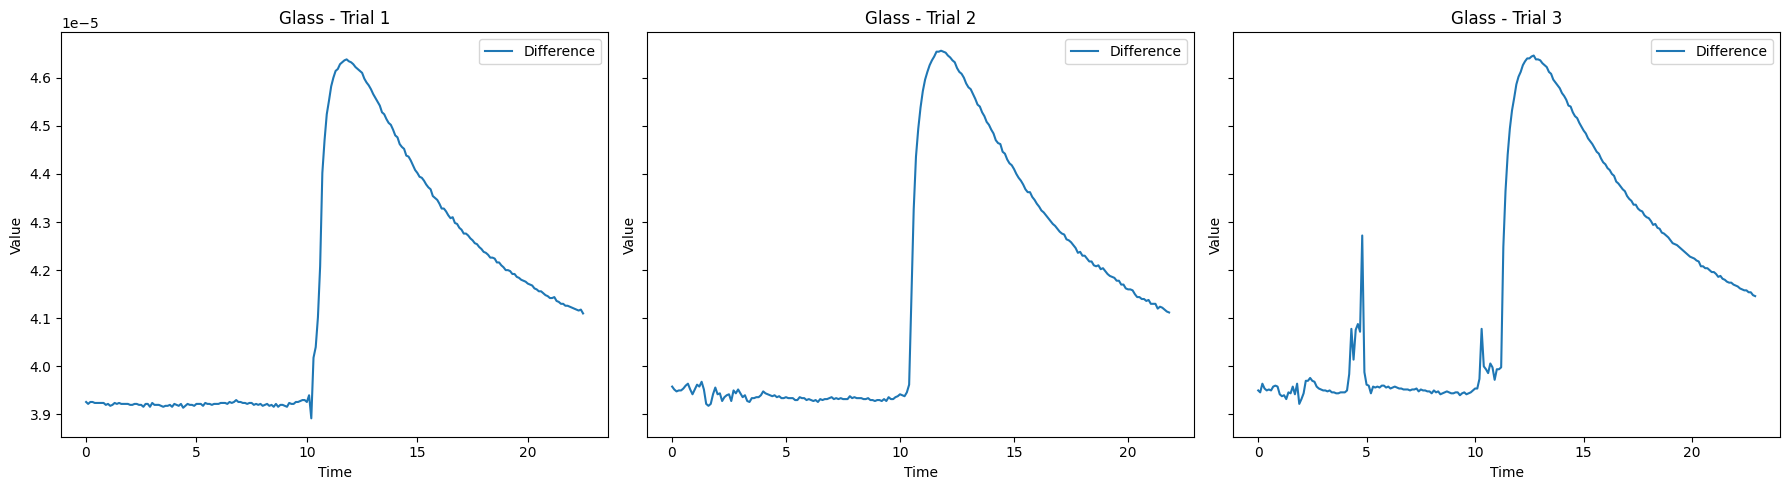

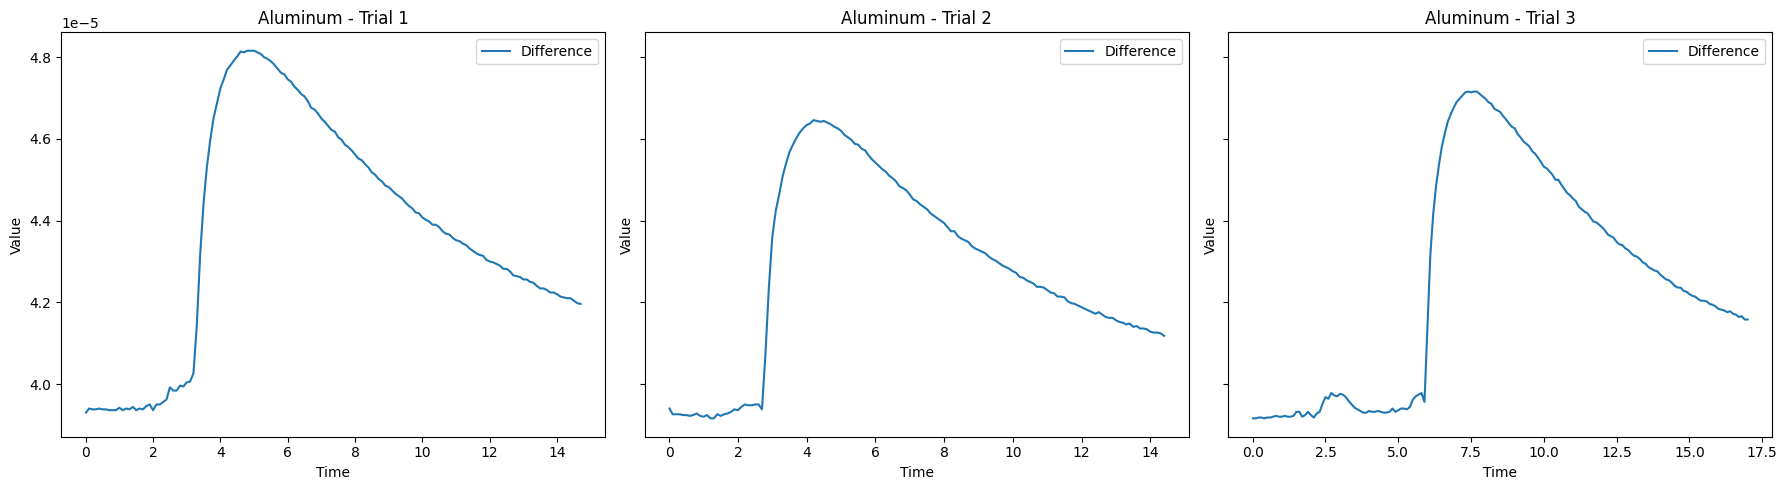

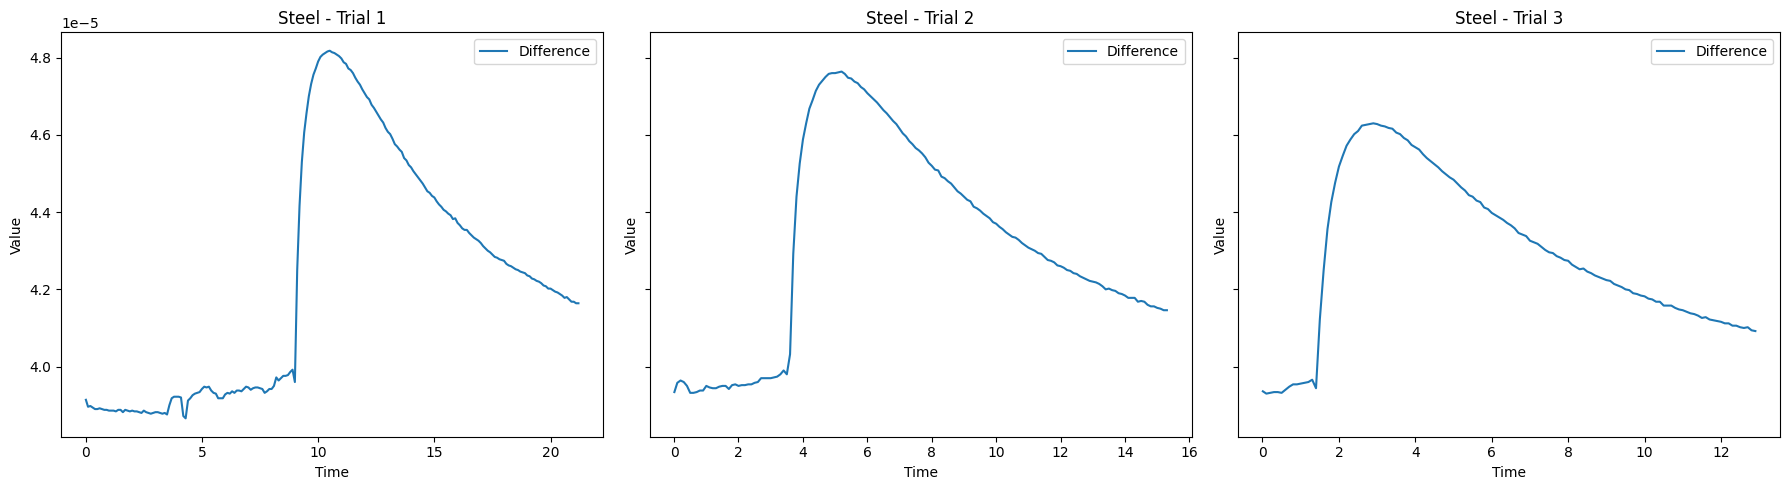

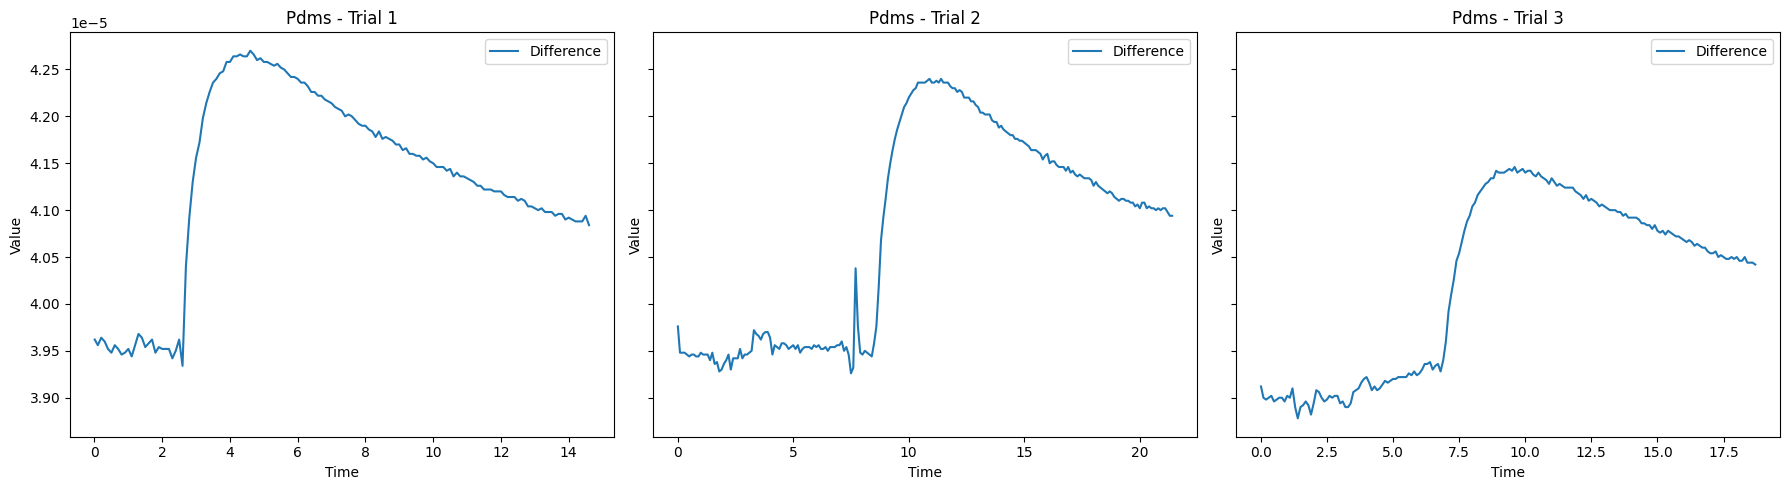

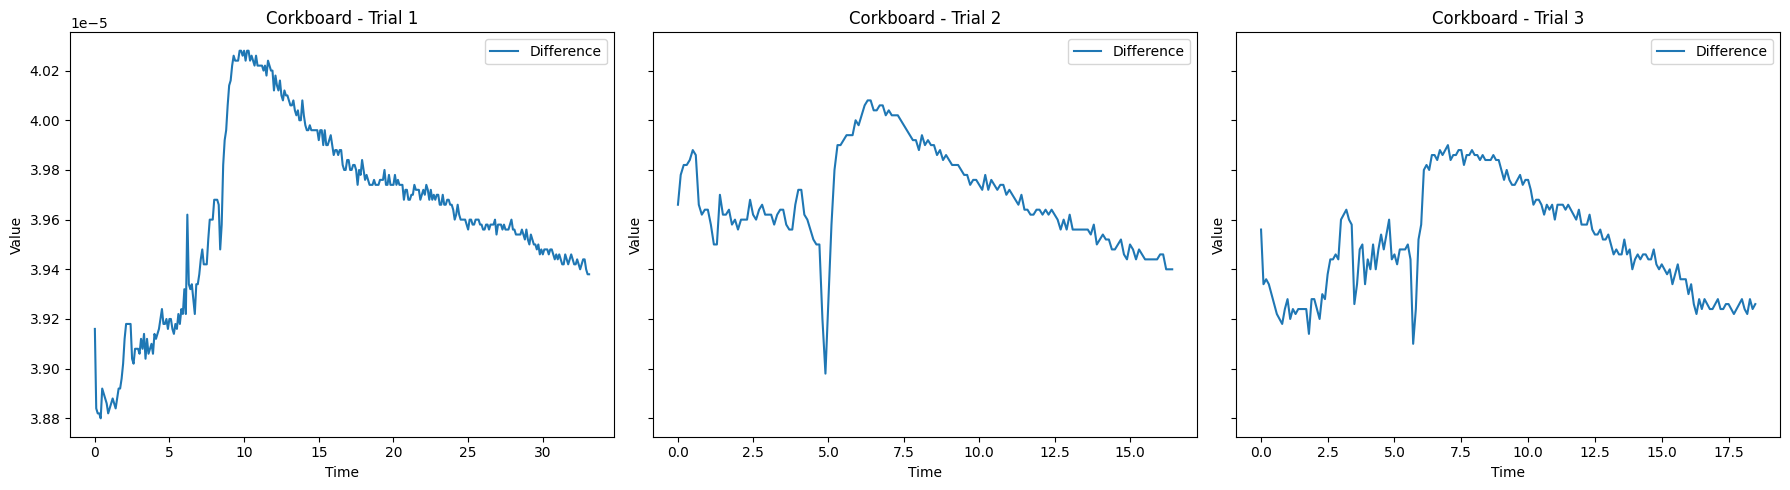

In [40]:
data['diff'] = data['Secondary'] - data['Primary']
data['abs_diff'] = data['diff'].abs()

# Plotting Primary and Secondary Readings Over Time
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['diff'], label='Difference')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Signal Cleaning

In [41]:
import numpy as np
from scipy.signal import savgol_filter

def find_global_first_elbow(
    subset,
    time_col="Time",
    signal_col="Primary",
    smooth_window=15,
    polyorder=2,
    pre_search_window=30,
    threshold_frac=0.15,
    direction="drop"
):
    """
    Finds elbow by first locating the strongest global slope change,
    then searching backward to find the clean start of the elbow.
    """

    df = subset.sort_values(time_col).copy()

    t = df[time_col].to_numpy(dtype=float)
    y = df[signal_col].to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    n = len(y)

    if n < 10:
        return np.nan, np.nan, None

    # Make SavGol window valid
    smooth_window = min(smooth_window, n - 1 if n % 2 == 0 else n)

    if smooth_window % 2 == 0:
        smooth_window -= 1

    if smooth_window <= polyorder:
        smooth_window = polyorder + 3
        if smooth_window % 2 == 0:
            smooth_window += 1

    # Smooth signal
    y_smooth = savgol_filter(y, window_length=smooth_window, polyorder=polyorder)

    # Derivative
    dy = np.gradient(y_smooth, t)

    # Find strongest global slope
    if direction == "drop":
        peak_idx = np.argmin(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope  # negative value
        active = dy < threshold

    elif direction == "rise":
        peak_idx = np.argmax(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope
        active = dy > threshold

    else:
        raise ValueError("direction must be 'drop' or 'rise'")

    # Search backward from strongest slope to find start of elbow
    start_idx = peak_idx

    for j in range(peak_idx, 0, -1):
        if not active[j]:
            start_idx = j + 1
            break

    # Optional refinement: search only near the strongest slope region
    start_idx = max(0, start_idx)

    return t[start_idx], y[start_idx], start_idx

glass - Trial 0 - 101
glass - Trial 1 - 101
glass - Trial 2 - 109


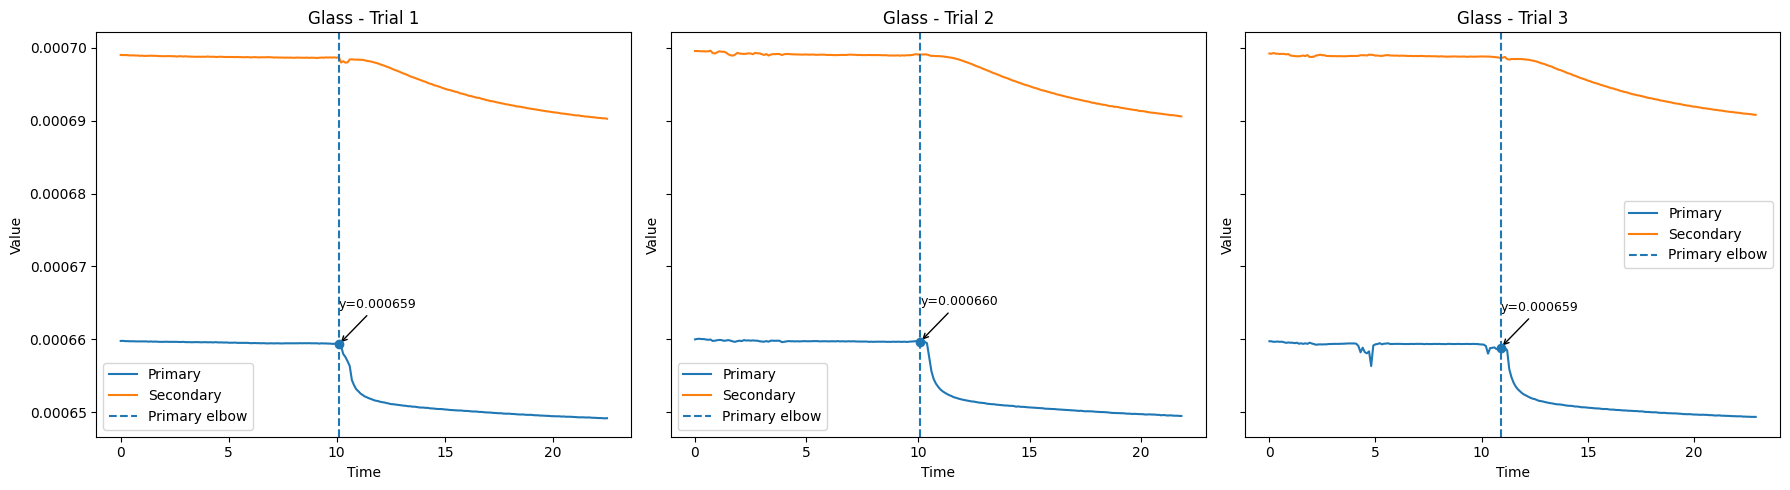

aluminum - Trial 0 - 30
aluminum - Trial 1 - 25
aluminum - Trial 2 - 56


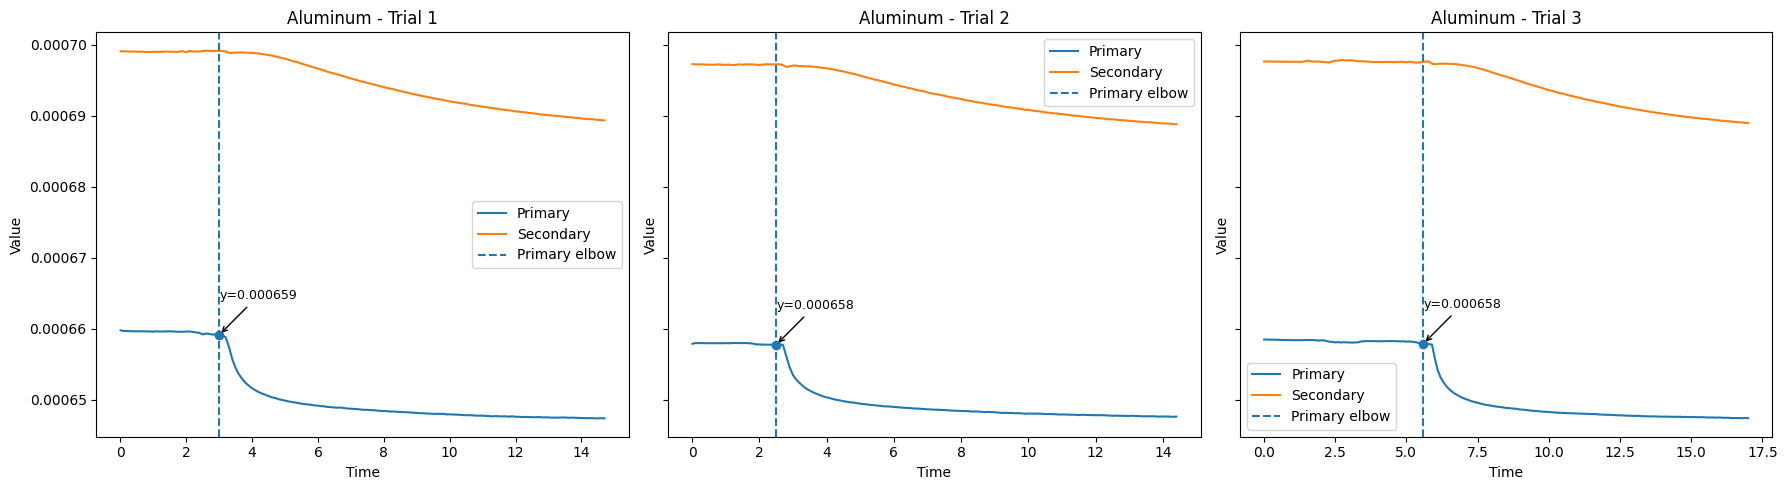

steel - Trial 0 - 87
steel - Trial 1 - 33
steel - Trial 2 - 12


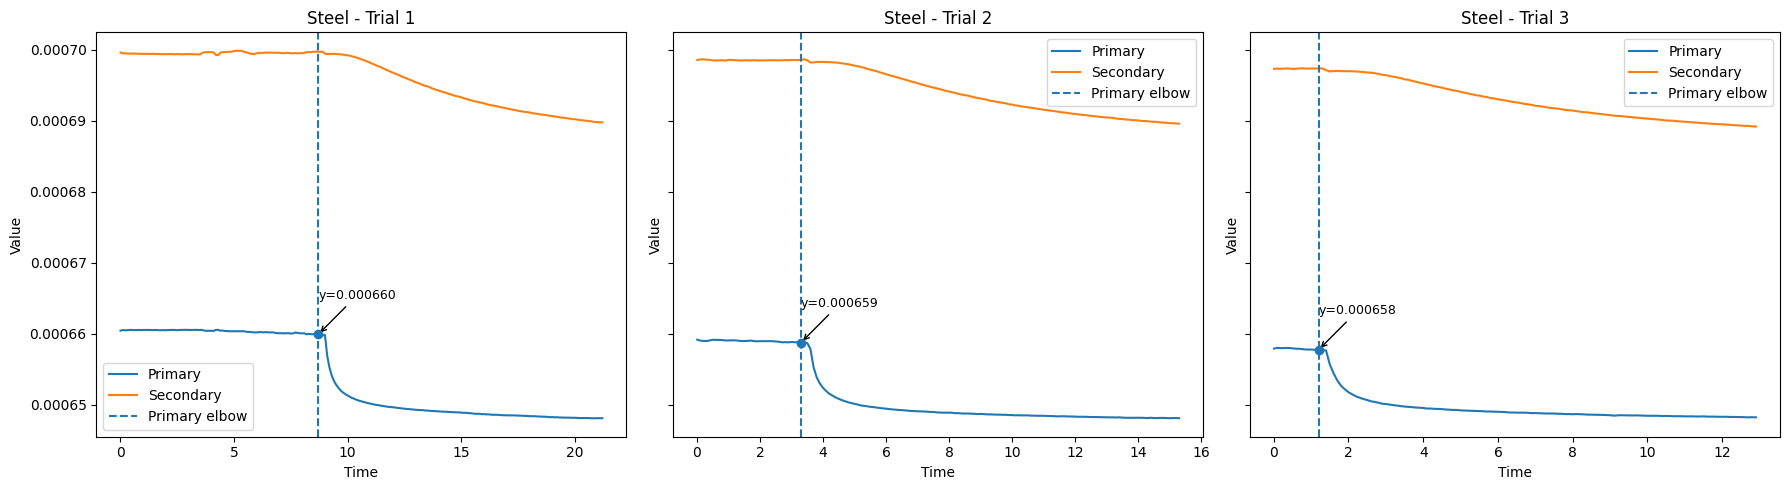

pdms - Trial 0 - 23
pdms - Trial 1 - 84
pdms - Trial 2 - 67


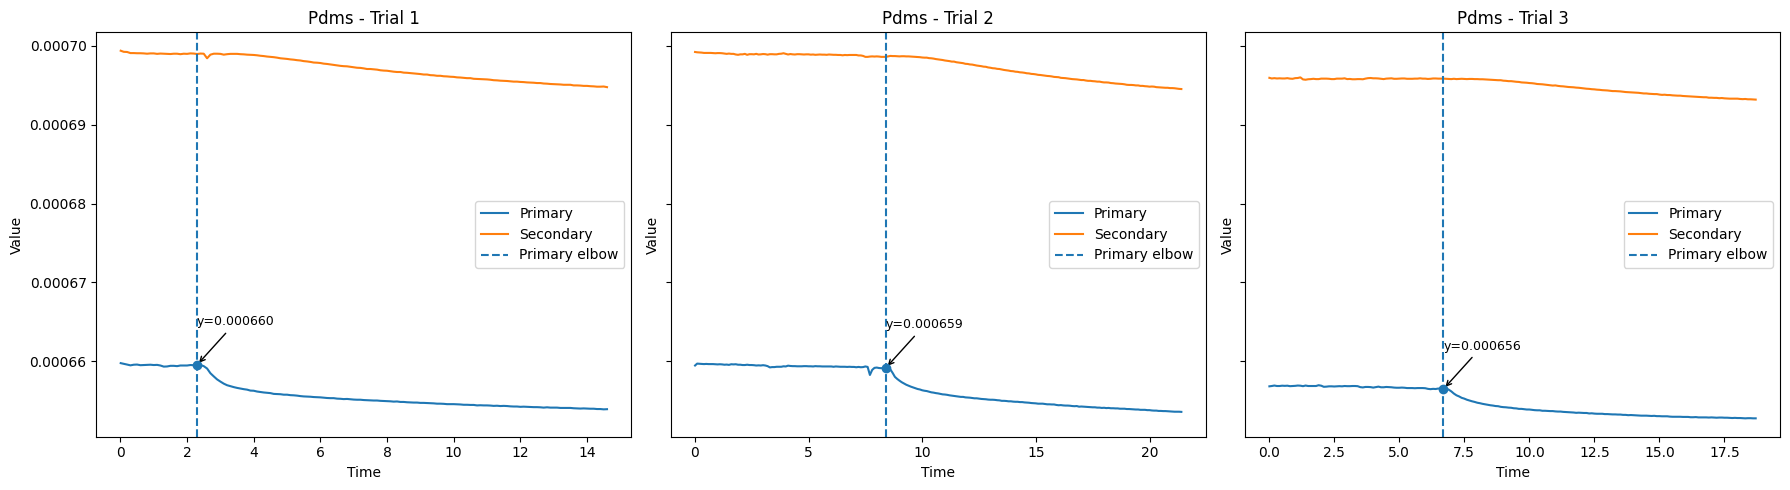

corkboard - Trial 0 - 81
corkboard - Trial 1 - 47
corkboard - Trial 2 - 54


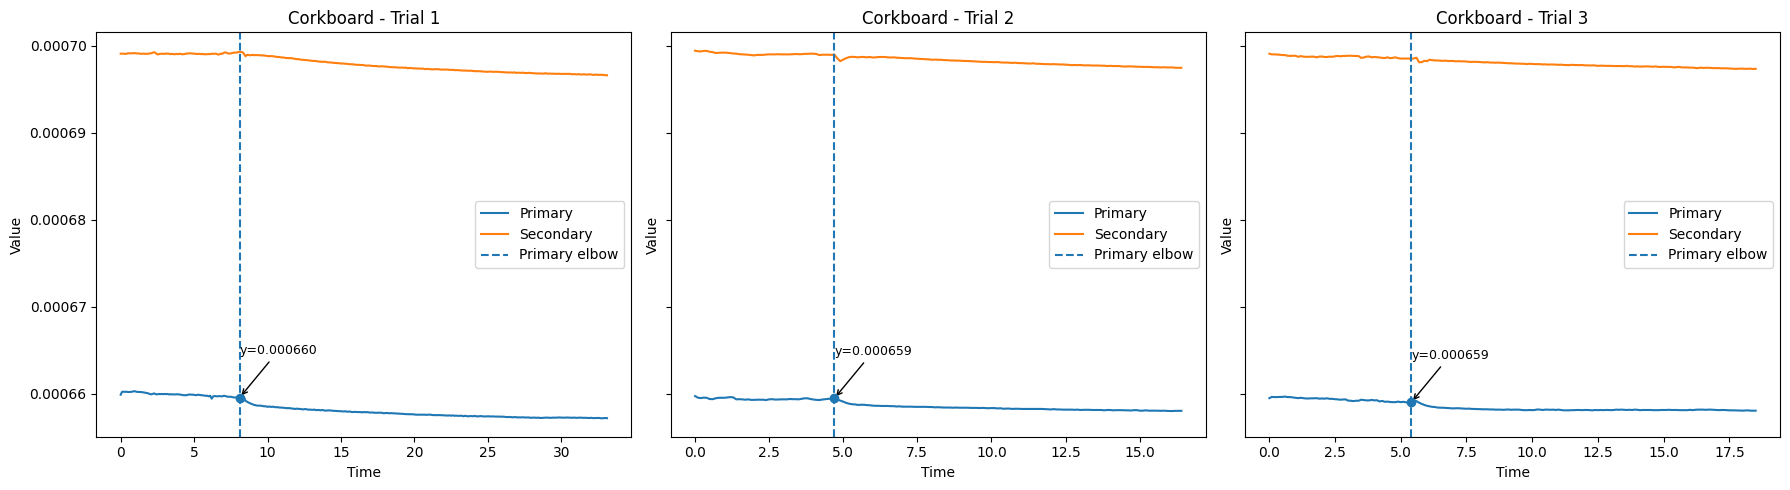

In [42]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)].copy()
        subset = subset.sort_values('Time')

        elbow_time, elbow_value, elbow_idx = find_global_first_elbow(
            subset,
            time_col="Time",
            signal_col="Primary",
            smooth_window=15,
            polyorder=2,
            threshold_frac=0.3,
            direction="drop"
        )
        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [43]:
data["is_elbow"] = False
data["elbow_time"] = np.nan
data["elbow_value"] = np.nan

for (sample, trial), subset in data.groupby(["Sample", "Trial"]):
    subset = subset.sort_values("Time").copy()

    elbow_time, elbow_value, elbow_idx = find_global_first_elbow(
            subset,
            time_col="Time",
            signal_col="Primary",
            smooth_window=15,
            polyorder=2,
            threshold_frac=0.3,
            direction="drop"
        )


    print(f"{sample} - Trial {trial} - {elbow_idx}")

    if not np.isnan(elbow_time):
        # find the actual row in the original dataframe closest to the elbow time
        elbow_row_idx = subset["Time"].sub(elbow_time).abs().idxmin()

        data.loc[elbow_row_idx, "is_elbow"] = True
        data.loc[elbow_row_idx, "elbow_time"] = elbow_time
        data.loc[elbow_row_idx, "elbow_value"] = elbow_value

aluminum - Trial 1.0 - 30
aluminum - Trial 2.0 - 25
aluminum - Trial 3.0 - 56
corkboard - Trial 1.0 - 81
corkboard - Trial 2.0 - 47
corkboard - Trial 3.0 - 54
glass - Trial 1.0 - 101
glass - Trial 2.0 - 101
glass - Trial 3.0 - 109
pdms - Trial 1.0 - 23
pdms - Trial 2.0 - 84
pdms - Trial 3.0 - 67
steel - Trial 1.0 - 87
steel - Trial 2.0 - 33
steel - Trial 3.0 - 12


In [44]:
# Get elbow time per Sample-Trial
elbow_times = (
    data.loc[data["is_elbow"], ["Sample", "Trial", "Time"]]
    .rename(columns={"Time": "elbow_time_new"})
)

# Add elbow_time back to main data
data = data.merge(
    elbow_times,
    on=["Sample", "Trial"],
    how="left"
)

# Create offsetted elbow time
data["elbow_time_offset"] = data["elbow_time_new"] - 1

# Mark rows from offsetted elbow time onward
data["filter_data"] = data["Time"] >= data["elbow_time_offset"]

# Create new time reference per Sample-Trial using offsetted elbow time
data["Time_new"] = np.nan

mask = data["filter_data"]

data.loc[mask, "Time_new"] = (
    data.loc[mask, "Time"] - data.loc[mask, "elbow_time_offset"]
)

# Cut at max 5 seconds
data["filter_data"] = data["filter_data"] & (data["Time_new"] <= 5)

# Remove Time_new for rows outside final filtered window
data.loc[~data["filter_data"], "Time_new"] = np.nan

data

,index,Sample,Trial,Time,Primary,Secondary,diff,abs_diff,is_elbow,elbow_time,elbow_value,elbow_time_new,elbow_time_offset,filter_data,Time_new
0,1.0,glass,1.0,0.00938,0.000660,0.000699,0.000039,0.000039,False,NaN,NaN,10.10071,9.10071,False,NaN
1,2.0,glass,1.0,0.10067,0.000660,0.000699,0.000039,0.000039,False,NaN,NaN,10.10071,9.10071,False,NaN
2,3.0,glass,1.0,0.20067,0.000660,0.000699,0.000039,0.000039,False,NaN,NaN,10.10071,9.10071,False,NaN
3,4.0,glass,1.0,0.30067,0.000660,0.000699,0.000039,0.000039,False,NaN,NaN,10.10071,9.10071,False,NaN
4,5.0,glass,1.0,0.40067,0.000660,0.000699,0.000039,0.000039,False,NaN,NaN,10.10071,9.10071,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2864,182.0,corkboard,3.0,18.10066,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,5.40066,4.40066,False,NaN
2865,183.0,corkboard,3.0,18.20066,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,5.40066,4.40066,False,NaN
2866,184.0,corkboard,3.0,18.30066,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,5.40066,4.40066,False,NaN
2867,185.0,corkboard,3.0,18.40066,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,5.40066,4.40066,False,NaN


In [45]:
data[(data['Sample'] == 'corkboard') & (data['Trial'] == 2)]

,index,Sample,Trial,Time,Primary,Secondary,diff,abs_diff,is_elbow,elbow_time,elbow_value,elbow_time_new,elbow_time_offset,filter_data,Time_new
2518,1.0,corkboard,2.0,0.00926,0.000660,0.000699,0.000040,0.000040,False,NaN,NaN,4.70066,3.70066,False,NaN
2519,2.0,corkboard,2.0,0.10070,0.000660,0.000699,0.000040,0.000040,False,NaN,NaN,4.70066,3.70066,False,NaN
2520,3.0,corkboard,2.0,0.20070,0.000660,0.000699,0.000040,0.000040,False,NaN,NaN,4.70066,3.70066,False,NaN
2521,4.0,corkboard,2.0,0.30066,0.000660,0.000699,0.000040,0.000040,False,NaN,NaN,4.70066,3.70066,False,NaN
2522,5.0,corkboard,2.0,0.40070,0.000660,0.000699,0.000040,0.000040,False,NaN,NaN,4.70066,3.70066,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2678,161.0,corkboard,2.0,16.00070,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,4.70066,3.70066,False,NaN
2679,162.0,corkboard,2.0,16.10071,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,4.70066,3.70066,False,NaN
2680,163.0,corkboard,2.0,16.20066,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,4.70066,3.70066,False,NaN
2681,164.0,corkboard,2.0,16.30070,0.000658,0.000697,0.000039,0.000039,False,NaN,NaN,4.70066,3.70066,False,NaN


In [46]:
# Get elbow y-value per Sample-Trial
elbow_y = (
    data.loc[data["is_elbow"], ["Sample", "Trial", "Primary"]]
    .rename(columns={"Primary": "elbow_y"})
)

# Average elbow y-value per material
material_elbow_avg = (
    elbow_y
    .groupby("Sample")["elbow_y"]
    .mean()
    .rename("material_elbow_avg")
    .reset_index()
)

# Add elbow_y and material average back to data
data = data.drop(columns=["elbow_y", "material_elbow_avg", "y_offset"], errors="ignore")

data = data.merge(elbow_y, on=["Sample", "Trial"], how="left")
data = data.merge(material_elbow_avg, on="Sample", how="left")

# Offset needed to align each trial elbow to the material average elbow
data["y_offset"] = data["material_elbow_avg"] - data["elbow_y"]

# Create shifted signals
data["Primary_shifted"] = data["Primary"] + data["y_offset"]
data["Secondary_shifted"] = data["Secondary"] + data["y_offset"]

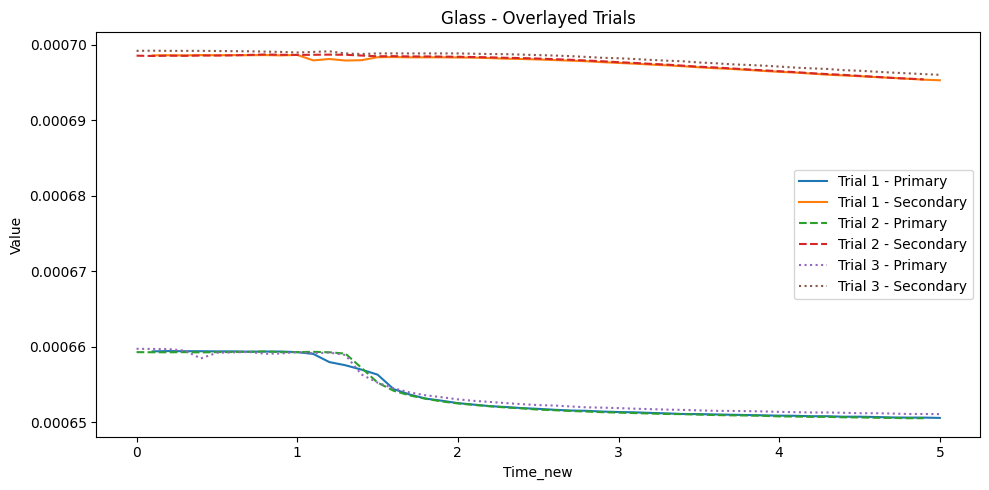

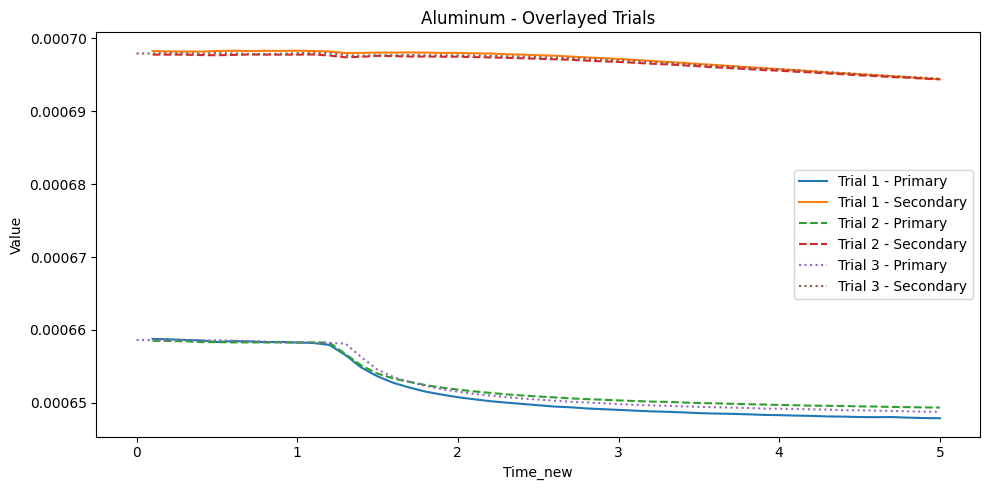

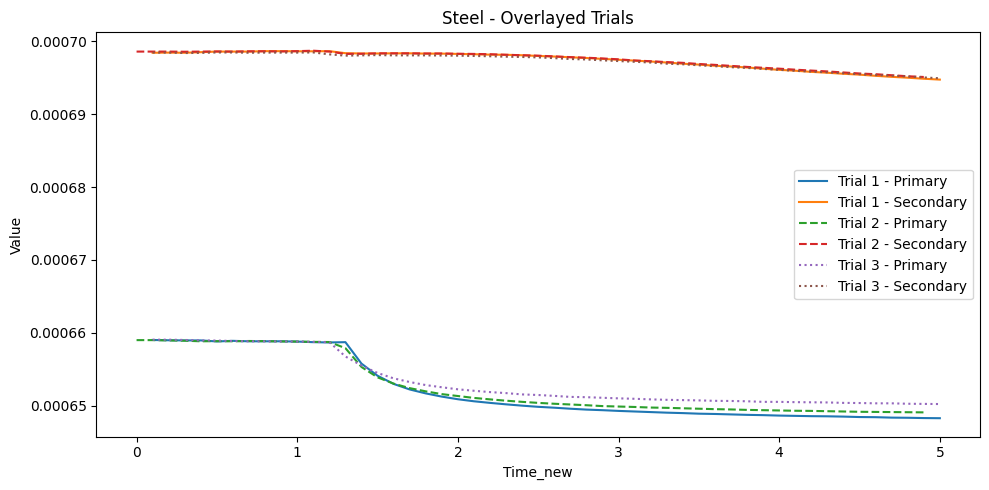

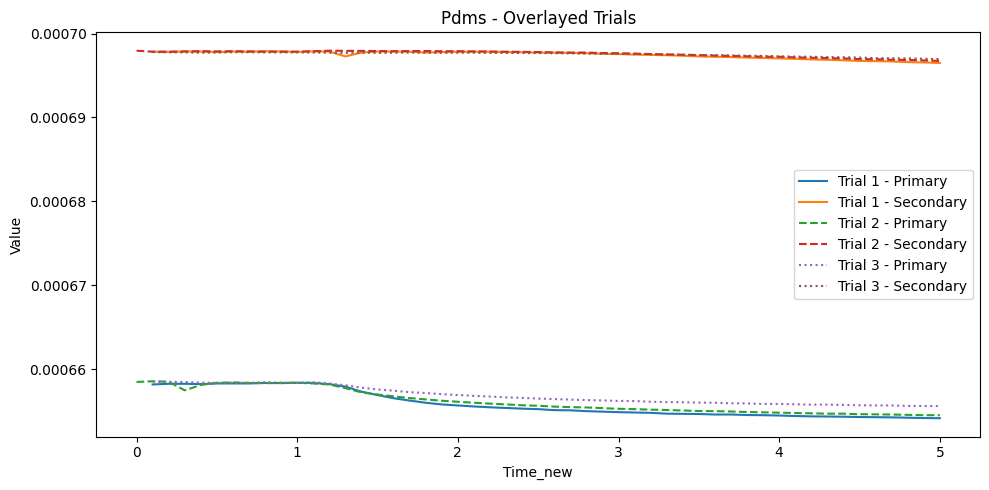

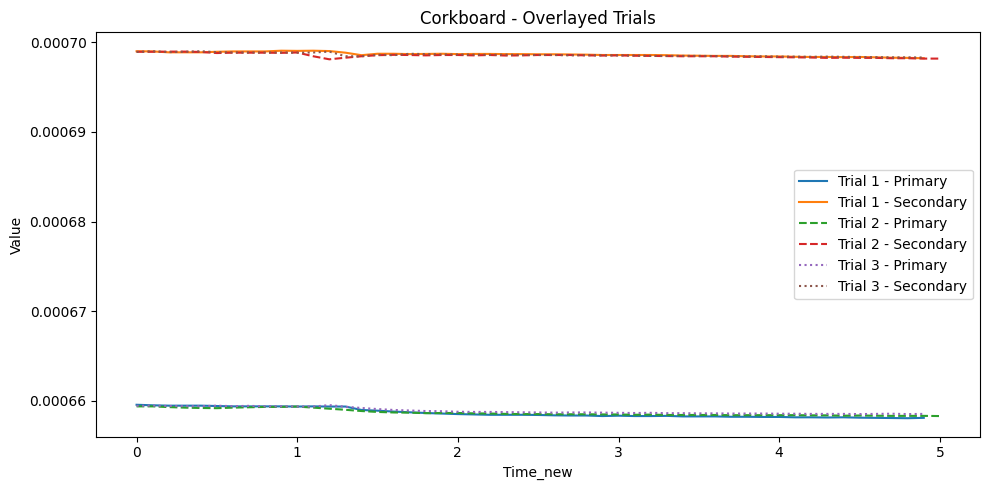

In [47]:
line_styles = {
    1: "-",
    2: "--",
    3: ":"
}

for m in materials:
    plt.figure(figsize=(10, 5))

    for i in range(3):
        trial_num = i + 1

        subset = data[
            (data["Sample"] == m) &
            (data["Trial"] == trial_num) &
            (data["filter_data"])
        ].copy()

        subset = subset.sort_values("Time_new")

        plt.plot(
            subset["Time_new"].values,
            subset["Primary_shifted"].values,
            linestyle=line_styles[trial_num],
            label=f"Trial {trial_num} - Primary"
        )

        plt.plot(
            subset["Time_new"].values,
            subset["Secondary_shifted"].values,
            linestyle=line_styles[trial_num],
            label=f"Trial {trial_num} - Secondary"
        )

    plt.xlabel("Time_new")
    plt.ylabel("Value")
    plt.title(f"{m.capitalize()} - Overlayed Trials")
    plt.legend()
    plt.tight_layout()
    plt.show()

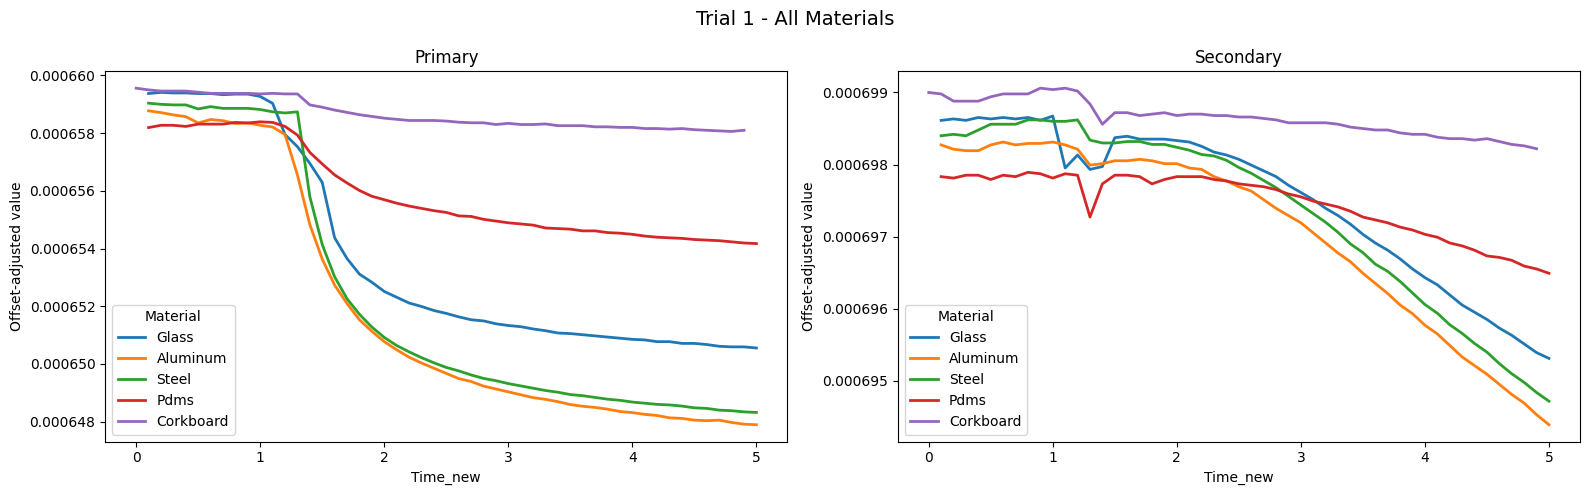

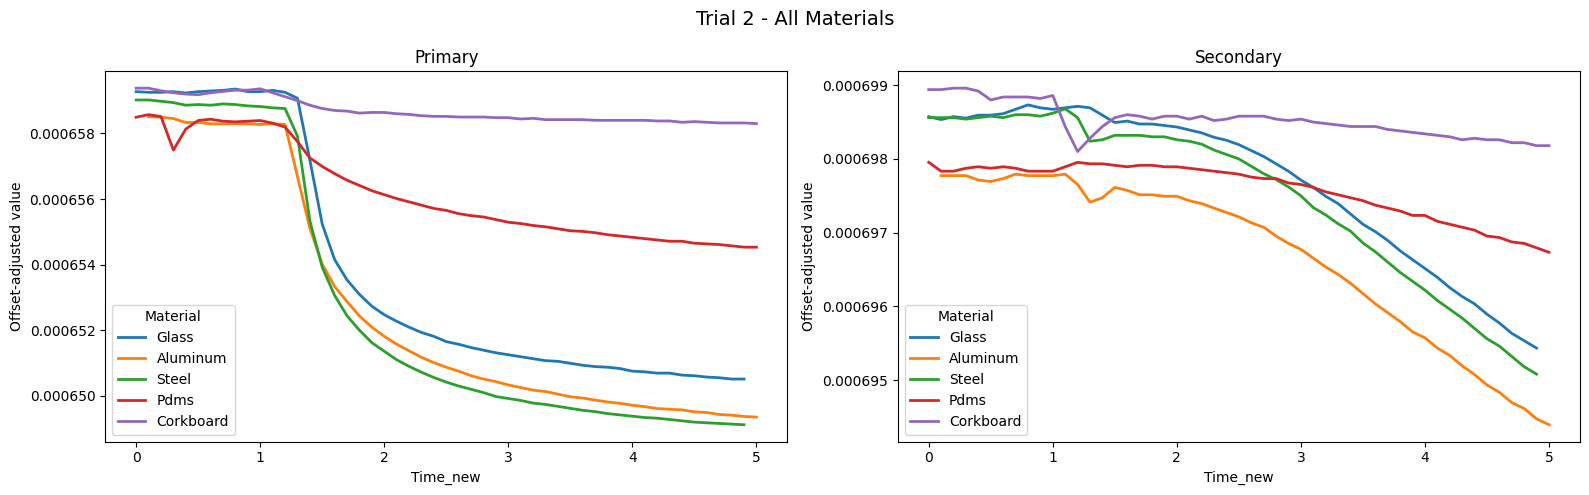

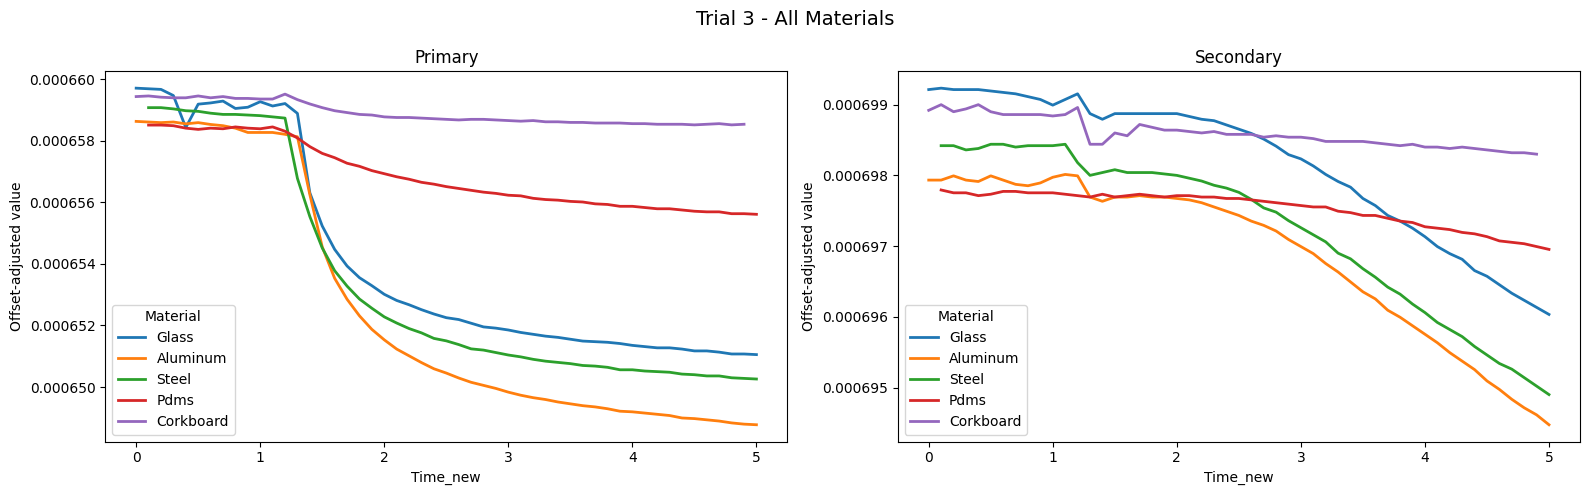

In [48]:
for trial_num in [1, 2, 3]:

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=False)

    ax_primary = axes[0]
    ax_secondary = axes[1]

    for m in materials:
        subset = data[
            (data["Sample"] == m) &
            (data["Trial"] == trial_num) &
            (data["filter_data"])
        ].copy()

        subset = subset.sort_values("Time_new")

        ax_primary.plot(
            subset["Time_new"],
            subset["Primary_shifted"],
            linewidth=2,
            label=m.capitalize()
        )

        ax_secondary.plot(
            subset["Time_new"],
            subset["Secondary_shifted"],
            linewidth=2,
            label=m.capitalize()
        )

    ax_primary.set_title("Primary")
    ax_secondary.set_title("Secondary")

    ax_primary.set_xlabel("Time_new")
    ax_secondary.set_xlabel("Time_new")

    ax_primary.set_ylabel("Offset-adjusted value")
    ax_secondary.set_ylabel("Offset-adjusted value")

    ax_primary.legend(title="Material")
    ax_secondary.legend(title="Material")

    fig.suptitle(f"Trial {trial_num} - All Materials", fontsize=14)

    plt.tight_layout()
    plt.show()

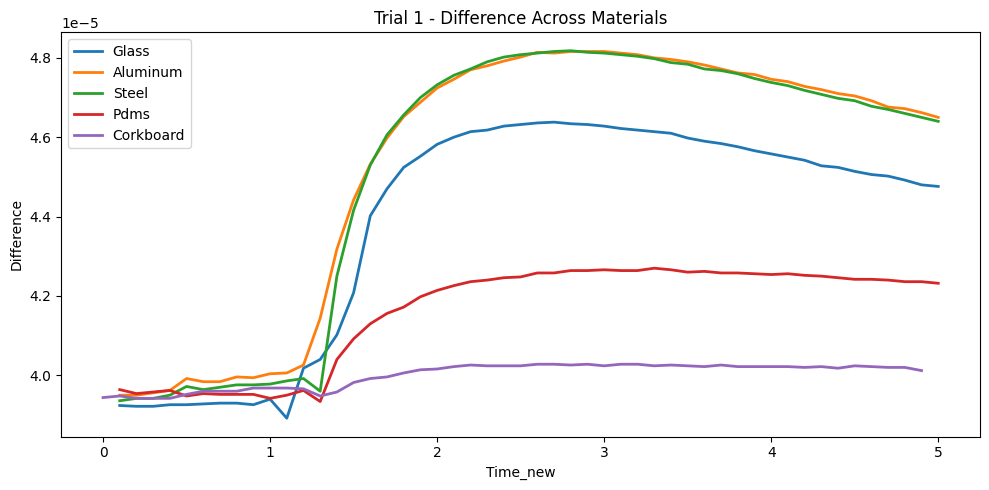

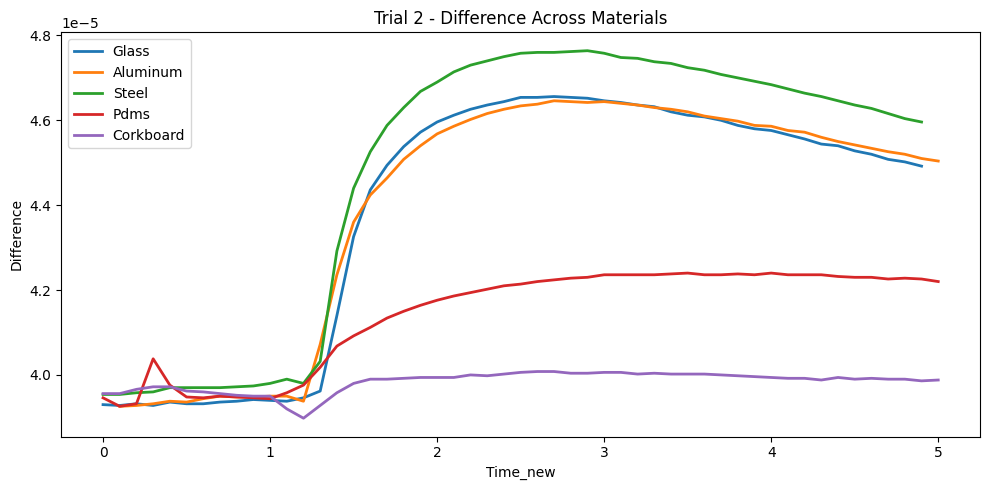

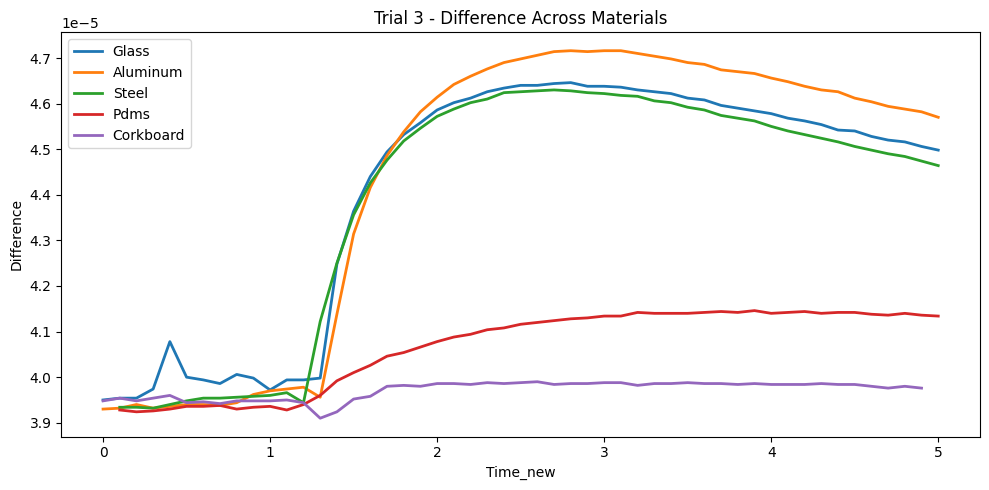

In [49]:
for trial_num in [1, 2, 3]:
    plt.figure(figsize=(10, 5))

    for m in materials:
        subset = data[
            (data["Sample"] == m) &
            (data["Trial"] == trial_num) &
            (data["filter_data"])
        ].copy()

        subset = subset.sort_values("Time_new")

        plt.plot(
            subset["Time_new"],
            subset["diff"],
            linewidth=2,
            label=f"{m.capitalize()}"
        )

    plt.xlabel("Time_new")
    plt.ylabel("Difference")
    plt.title(f"Trial {trial_num} - Difference Across Materials")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Feature Engineering

The raw sensor data is a time-series signal, where each material trial contains `Primary` and `Secondary` responses over time. Since most machine learning models require fixed-length inputs, each trial must be converted into a numerical vector. This vector is called an **embedding**.

In this project, each embedding represents the important shape and response behavior of one trial, such as signal magnitude, slope, delay, drift, and response timing.

The following embedding approaches will be compared:

1. **Manual response features**  
   Physically meaningful features such as baseline, minimum value, percent change, slope, time-to-minimum, and area under the curve.

2. **Statistical time-series features**  
   Automatic features from methods such as `tsfresh`, including statistics, trends, autocorrelation, entropy, and peak-based features.

3. **Convolutional time-series embeddings**  
   Methods such as MiniROCKET or MultiROCKET that capture local curve patterns using convolutional kernels.

4. **Reservoir computing embeddings**  
   Dynamic embeddings generated from reservoir states, useful for capturing temporal memory and nonlinear response behavior.

Each embedding method will be used to train the same classifier pipeline. Their performance will be compared using accuracy, confusion matrix, and material-wise classification results.

## Manual Features

1. Get Rough Summary

In [93]:
summary = data[data['filter_data'] == True].groupby(['Sample', 'Trial'])[['Primary_shifted', 'Secondary_shifted', 'diff']].describe()
summary = summary.drop(columns='count', level=1)
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.head()

,Sample,Trial,Primary_shifted_mean,Primary_shifted_std,Primary_shifted_min,Primary_shifted_25%,Primary_shifted_50%,Primary_shifted_75%,Primary_shifted_max,Secondary_shifted_mean,...,Secondary_shifted_50%,Secondary_shifted_75%,Secondary_shifted_max,diff_mean,diff_std,diff_min,diff_25%,diff_50%,diff_75%,diff_max
0,aluminum,1.0,0.000652,4.178343e-06,0.000648,0.000648,0.000650,0.000656,0.000659,0.000697,...,0.000698,0.000698,0.000698,0.000045,3.353597e-06,0.000040,0.000042,0.000047,0.000048,0.000048
1,aluminum,2.0,0.000653,3.556530e-06,0.000649,0.000650,0.000651,0.000656,0.000659,0.000697,...,0.000697,0.000698,0.000698,0.000044,2.826508e-06,0.000039,0.000041,0.000045,0.000046,0.000046
2,aluminum,3.0,0.000653,3.950057e-06,0.000649,0.000649,0.000650,0.000658,0.000659,0.000697,...,0.000697,0.000698,0.000698,0.000044,3.198416e-06,0.000039,0.000040,0.000046,0.000047,0.000047
3,corkboard,1.0,0.000659,5.211316e-07,0.000658,0.000658,0.000658,0.000659,0.000660,0.000699,...,0.000699,0.000699,0.000699,0.000040,3.156399e-07,0.000039,0.000040,0.000040,0.000040,0.000040
4,corkboard,2.0,0.000659,3.709655e-07,0.000658,0.000658,0.000659,0.000659,0.000659,0.000699,...,0.000699,0.000699,0.000699,0.000040,2.452549e-07,0.000039,0.000040,0.000040,0.000040,0.000040


In [94]:
summary_cols = [c for c in summary.columns if c not in ['Sample', 'Trial']]
for c in summary_cols:
    display(c)
    display(summary.groupby('Sample')[c].describe())

'Primary_shifted_mean'

,count,mean,std,min,25%,50%,75%,max
Sample,,,,,,,,
aluminum,3.0,0.000652,4.859165e-07,0.000652,0.000652,0.000653,0.000653,0.000653
corkboard,3.0,0.000659,1.267091e-07,0.000659,0.000659,0.000659,0.000659,0.000659
glass,3.0,0.000654,2.276273e-07,0.000654,0.000654,0.000654,0.000654,0.000654
pdms,3.0,0.000656,5.017729e-07,0.000656,0.000656,0.000656,0.000657,0.000657
steel,3.0,0.000653,5.722159e-07,0.000652,0.000652,0.000653,0.000653,0.000653


'Primary_shifted_std'

,count,mean,std,min,25%,50%,75%,max
Sample,,,,,,,,
aluminum,3.0,3.894976e-06,3.145445e-07,3.556530e-06,3.753293e-06,3.950057e-06,4.064200e-06,4.178343e-06
corkboard,3.0,4.165016e-07,9.086546e-08,3.574077e-07,3.641866e-07,3.709655e-07,4.460485e-07,5.211316e-07
glass,3.0,3.507260e-06,1.437644e-07,3.362873e-06,3.435693e-06,3.508513e-06,3.579453e-06,3.650394e-06
pdms,3.0,1.366214e-06,2.734592e-07,1.060763e-06,1.255194e-06,1.449625e-06,1.518940e-06,1.588254e-06
steel,3.0,3.922056e-06,4.280083e-07,3.450423e-06,3.740190e-06,4.029957e-06,4.157873e-06,4.285789e-06


'Primary_shifted_min'

...

,count,mean,std,min,25%,50%,75%,max
Sample,,,,,,,,
aluminum,3.0,0.000046,8.093413e-07,0.000045,0.000046,0.000046,0.000047,0.000047
corkboard,3.0,0.000040,1.929594e-07,0.000040,0.000040,0.000040,0.000040,0.000040
glass,3.0,0.000045,9.237604e-08,0.000045,0.000045,0.000045,0.000045,0.000045
pdms,3.0,0.000042,6.349803e-07,0.000041,0.000042,0.000042,0.000042,0.000042
steel,3.0,0.000046,9.209415e-07,0.000045,0.000046,0.000047,0.000047,0.000047


'diff_75%'

,count,mean,std,min,25%,50%,75%,max
Sample,,,,,,,,
aluminum,3.0,0.000047,8.407487e-07,0.000046,0.000046,0.000047,0.000047,0.000048
corkboard,3.0,0.000040,1.913984e-07,0.000040,0.000040,0.000040,0.000040,0.000040
glass,3.0,0.000046,5.267827e-08,0.000046,0.000046,0.000046,0.000046,0.000046
pdms,3.0,0.000042,6.256264e-07,0.000041,0.000042,0.000042,0.000042,0.000043
steel,3.0,0.000047,9.339834e-07,0.000046,0.000047,0.000047,0.000048,0.000048


'diff_max'

,count,mean,std,min,25%,50%,75%,max
Sample,,,,,,,,
aluminum,3.0,0.000047,8.544004e-07,0.000046,0.000047,0.000047,0.000048,0.000048
corkboard,3.0,0.000040,1.900877e-07,0.000040,0.000040,0.000040,0.000040,0.000040
glass,3.0,0.000046,9.018500e-08,0.000046,0.000046,0.000046,0.000047,0.000047
pdms,3.0,0.000042,6.469415e-07,0.000041,0.000042,0.000042,0.000043,0.000043
steel,3.0,0.000047,9.679532e-07,0.000046,0.000047,0.000048,0.000048,0.000048


### Principal Component Analysis (2 PCs)

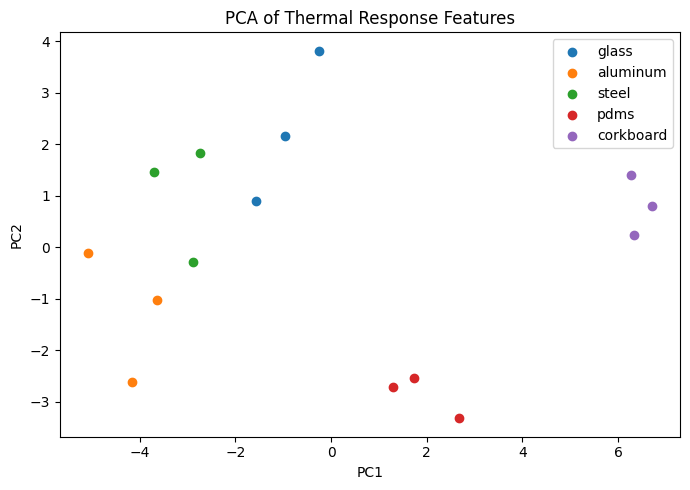

[7.16730767e-01 1.93446639e-01 4.58450854e-02 3.99433176e-02
 2.32797069e-03 9.10112030e-04 4.27351297e-04 2.00455335e-04
 1.30040613e-04 2.33909779e-05 9.31227743e-06 4.08852116e-06
 9.43376419e-07 5.26485208e-07 1.61383518e-33]


In [99]:
feature_cols = summary.drop(columns=["Sample", "Trial"]).columns

X = summary[feature_cols]
y = summary["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in materials:
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

### Convex Hull Boundaries

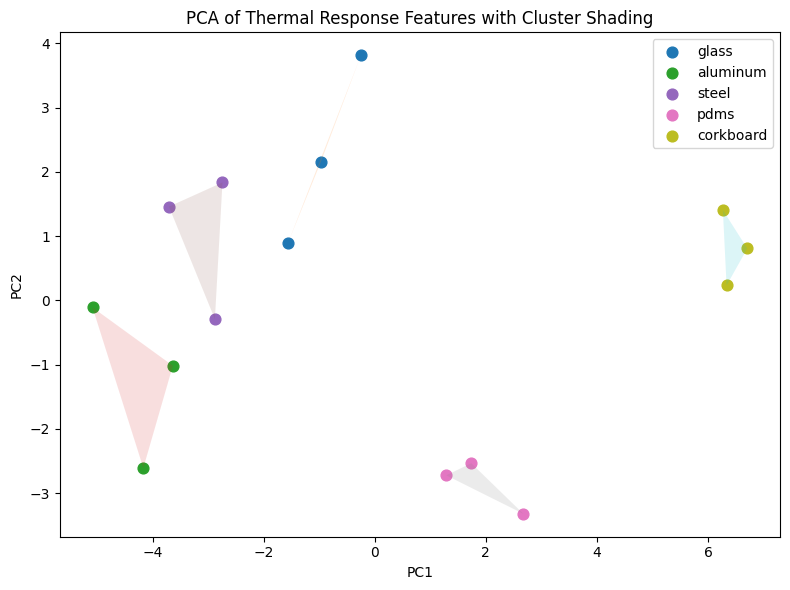

In [100]:
plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

    # shade cluster area
    if mask.sum() >= 3:
        points = X_pca[mask, :2]
        hull = ConvexHull(points)

        plt.fill(
            points[hull.vertices, 0],
            points[hull.vertices, 1],
            alpha=0.15
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features with Cluster Shading")
plt.legend()
plt.tight_layout()
plt.show()

### SVM Boundaries

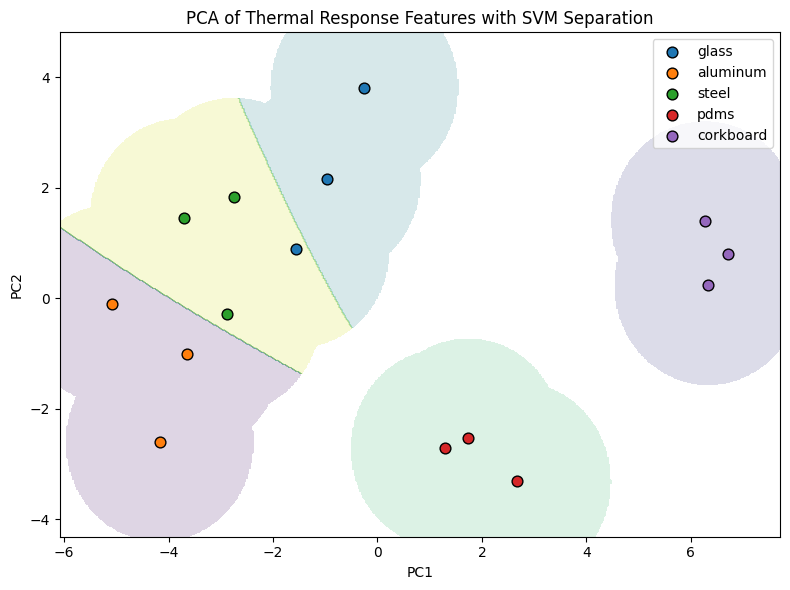

In [106]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

clf = SVC(
    kernel="rbf",
    C=0.5,
    gamma="scale"
)

clf.fit(X_pca[:, :2], y_encoded)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = clf.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# limit shading only near actual data points
grid = np.c_[xx.ravel(), yy.ravel()]

distances = np.min(
    np.sqrt(
        (grid[:, 0, None] - X_pca[:, 0])**2 +
        (grid[:, 1, None] - X_pca[:, 1])**2
    ),
    axis=1
)

distances = distances.reshape(xx.shape)

# tune this
Z = np.where(distances <= 1.8, Z, np.nan)
Z = np.ma.masked_invalid(Z)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.18
)

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60,
        edgecolor="k"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features with SVM Separation")
plt.legend()
plt.tight_layout()
plt.show()

### Factor Loadings

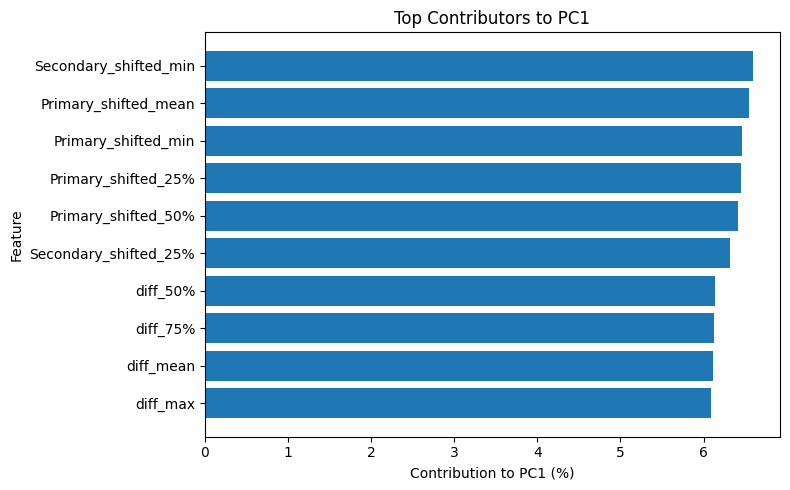

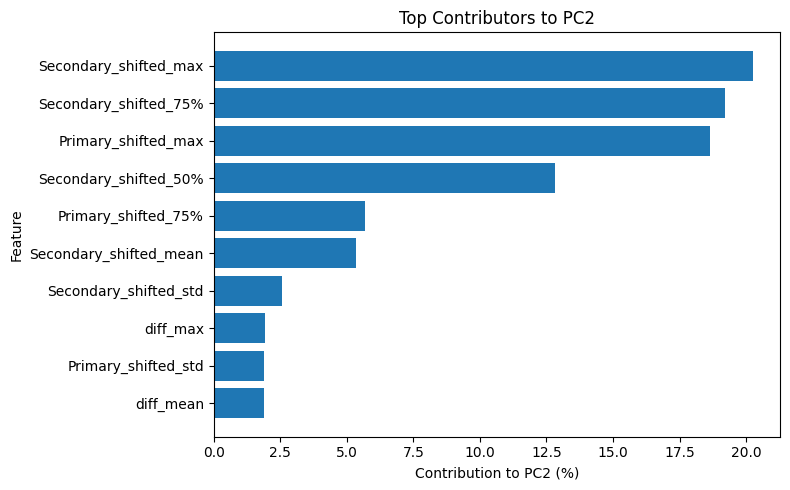

In [107]:
# loadings for all PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# percent contribution per feature per PC
contributions = loadings.pow(2)

contributions = contributions.div(
    contributions.sum(axis=0),
    axis=1
) * 100

top_n = 10

pc1_contributors = (
    contributions["PC1"]
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc1_contributors.index[::-1],
    pc1_contributors.values[::-1]
)

plt.xlabel("Contribution to PC1 (%)")
plt.ylabel("Feature")
plt.title("Top Contributors to PC1")
plt.tight_layout()
plt.show()

pc2_contributors = (
    contributions["PC2"]
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc2_contributors.index[::-1],
    pc2_contributors.values[::-1]
)

plt.xlabel("Contribution to PC2 (%)")
plt.ylabel("Feature")
plt.title("Top Contributors to PC2")
plt.tight_layout()
plt.show()

### Cumulative Variance Explained

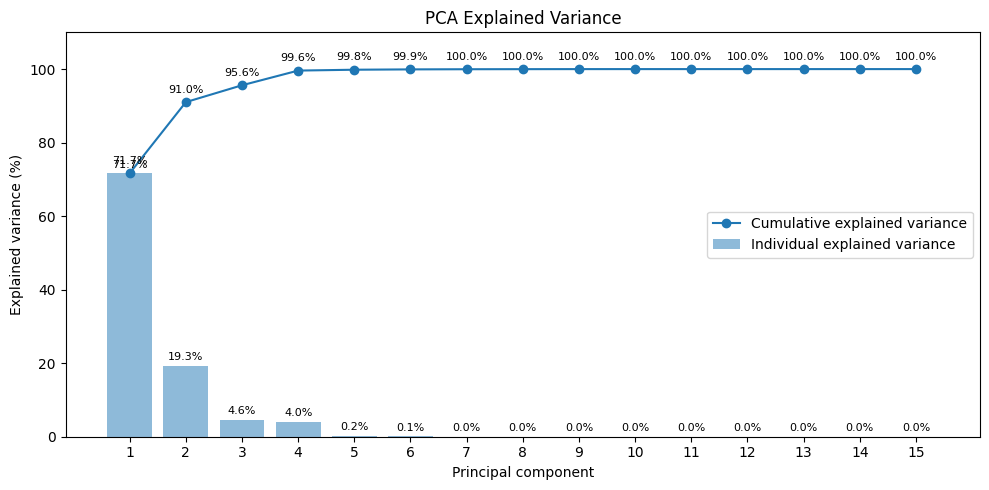

In [108]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

## `tsfresh` Features

In [111]:
# use only filtered data
ts_data = data[data["filter_data"]].copy()

# create one ID per material-trial
ts_data["id"] = (
    ts_data["Sample"].astype(str) +
    "_trial_" +
    ts_data["Trial"].astype(int).astype(str)
)

# primary sensor table
primary = ts_data[[
    "id",
    "Time_new",
    "Primary_shifted"
]].copy()

primary = primary.rename(columns={
    "Time_new": "time",
    "Primary_shifted": "value"
})

primary["kind"] = "Primary"

# secondary sensor table
secondary = ts_data[[
    "id",
    "Time_new",
    "Secondary_shifted"
]].copy()

secondary = secondary.rename(columns={
    "Time_new": "time",
    "Secondary_shifted": "value"
})

secondary["kind"] = "Secondary"


# diff sensor table
diff = ts_data[[
    "id",
    "Time_new",
    "diff"
]].copy()

diff = diff.rename(columns={
    "Time_new": "time",
    "diff": "value"
})

diff["kind"] = "Difference"

# combine primary and secondary
tsfresh_input = pd.concat(
    [primary, secondary, diff],
    ignore_index=True
)

tsfresh_input = tsfresh_input[[
    "id",
    "time",
    "kind",
    "value"
]]

# clean invalid values
tsfresh_input = tsfresh_input.replace([np.inf, -np.inf], np.nan)
tsfresh_input = tsfresh_input.dropna()

tsfresh_input.head()

,id,time,kind,value
0,glass_trial_1,0.09996,Primary,0.000659
1,glass_trial_1,0.20000,Primary,0.000659
2,glass_trial_1,0.30000,Primary,0.000659
3,glass_trial_1,0.40000,Primary,0.000659
4,glass_trial_1,0.49996,Primary,0.000659


In [129]:
settings = EfficientFCParameters()

tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    default_fc_parameters=settings,
    n_jobs=0
)

Feature Extraction: 100%|██████████| 45/45 [00:00<00:00, 50.97it/s]


In [130]:
labels = (
    ts_data[["id", "Sample", "Trial"]]
    .drop_duplicates()
    .set_index("id")
)
tsfresh_features = tsfresh_features.dropna(axis=1)


tsfresh_features = tsfresh_features.join(labels)
tsfresh_features = tsfresh_features.reset_index()
tsfresh_features.head()

,index,Difference__variance_larger_than_standard_deviation,Difference__has_duplicate_max,Difference__has_duplicate_min,Difference__has_duplicate,Difference__sum_values,Difference__abs_energy,Difference__mean_abs_change,Difference__mean_change,Difference__mean_second_derivative_central,...,Secondary__fourier_entropy__bins_10,Secondary__fourier_entropy__bins_100,Secondary__permutation_entropy__dimension_3__tau_1,Secondary__permutation_entropy__dimension_4__tau_1,Secondary__permutation_entropy__dimension_5__tau_1,Secondary__permutation_entropy__dimension_6__tau_1,Secondary__permutation_entropy__dimension_7__tau_1,Secondary__mean_n_absolute_max__number_of_maxima_7,Sample,Trial
0,aluminum_trial_1,0.0,1.0,1.0,1.0,0.002266,1.032879e-07,2.155102e-07,1.428571e-07,-1.250000e-09,...,0.324508,0.484390,1.010287,1.495861,1.833855,1.924207,1.955283,0.000698,aluminum,1.0
1,aluminum_trial_2,0.0,0.0,0.0,1.0,0.002203,9.742921e-08,1.832653e-07,1.179592e-07,-8.333333e-10,...,0.324508,0.484390,1.133130,1.647402,1.863992,1.924207,1.955283,0.000698,aluminum,2.0
2,aluminum_trial_3,0.0,0.0,0.0,1.0,0.002263,1.008858e-07,2.000000e-07,1.280000e-07,-1.428571e-09,...,0.431071,0.431071,1.007629,1.429448,1.717526,1.833855,1.924207,0.000698,aluminum,3.0
3,corkboard_trial_1,0.0,1.0,1.0,1.0,0.002000,8.001288e-08,4.000000e-08,1.387755e-08,-1.250000e-09,...,0.163024,1.023669,1.568906,2.476263,3.089994,3.456163,3.658163,0.000699,corkboard,1.0
4,corkboard_trial_2,0.0,1.0,0.0,1.0,0.002031,8.091168e-08,5.040000e-08,6.400000e-09,2.040816e-10,...,1.231974,2.628675,1.651900,2.722804,3.313850,3.666582,3.775856,0.000699,corkboard,2.0


### Principal Component Analysis

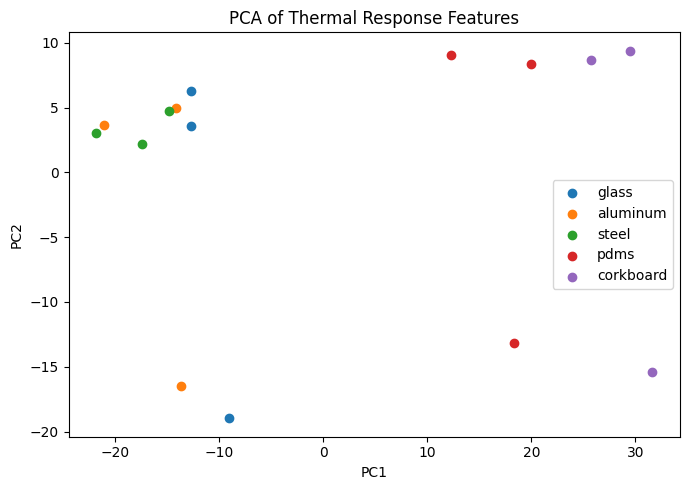

[4.89643944e-01 1.28673113e-01 1.17101980e-01 7.04783794e-02
 3.91764293e-02 3.10672242e-02 2.85447795e-02 2.14752958e-02
 1.90804564e-02 1.51128702e-02 1.45679996e-02 1.29864602e-02
 7.14101324e-03 4.95005451e-03 6.18611012e-33]


In [133]:
feature_cols = tsfresh_features.drop(columns=["index", "Sample", "Trial"]).columns
feature_cols = [c for c in feature_cols if 'Difference' not in c]

X = tsfresh_features[feature_cols]
y = tsfresh_features["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in materials:
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

### Convex Hull Boundaries

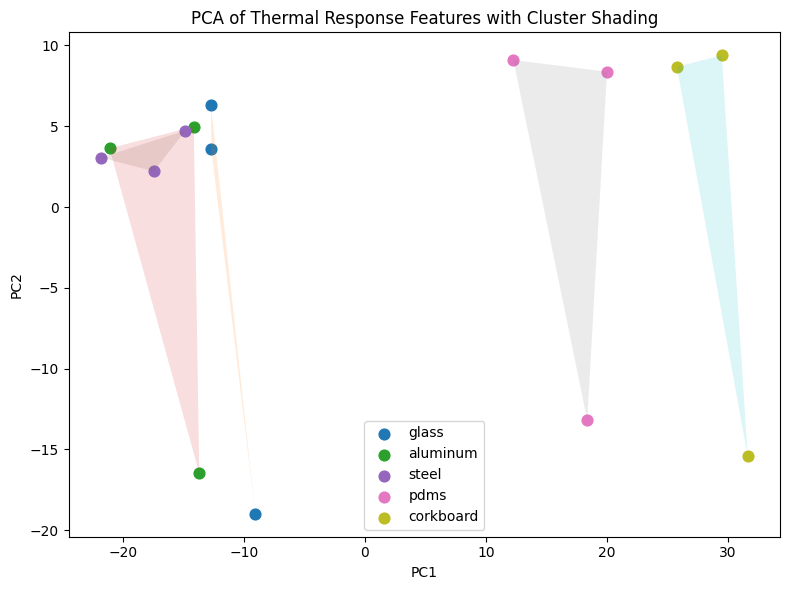

In [135]:
plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

    # shade cluster area
    if mask.sum() >= 3:
        points = X_pca[mask, :2]
        hull = ConvexHull(points)

        plt.fill(
            points[hull.vertices, 0],
            points[hull.vertices, 1],
            alpha=0.15
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features with Cluster Shading")
plt.legend()
plt.tight_layout()
plt.show()

### SVM Boundaries

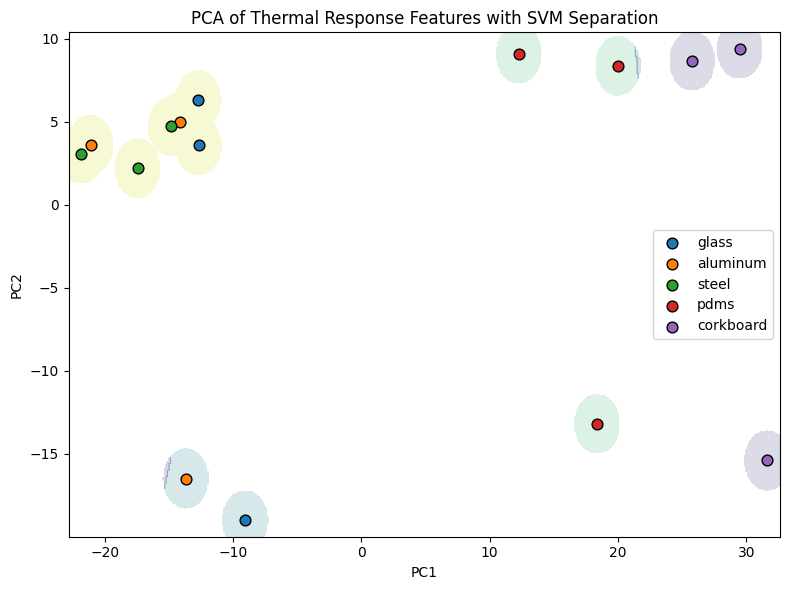

In [136]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

clf = SVC(
    kernel="rbf",
    C=0.5,
    gamma="scale"
)

clf.fit(X_pca[:, :2], y_encoded)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = clf.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# limit shading only near actual data points
grid = np.c_[xx.ravel(), yy.ravel()]

distances = np.min(
    np.sqrt(
        (grid[:, 0, None] - X_pca[:, 0])**2 +
        (grid[:, 1, None] - X_pca[:, 1])**2
    ),
    axis=1
)

distances = distances.reshape(xx.shape)

# tune this
Z = np.where(distances <= 1.8, Z, np.nan)
Z = np.ma.masked_invalid(Z)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.18
)

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60,
        edgecolor="k"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features with SVM Separation")
plt.legend()
plt.tight_layout()
plt.show()

### Factor Loadings

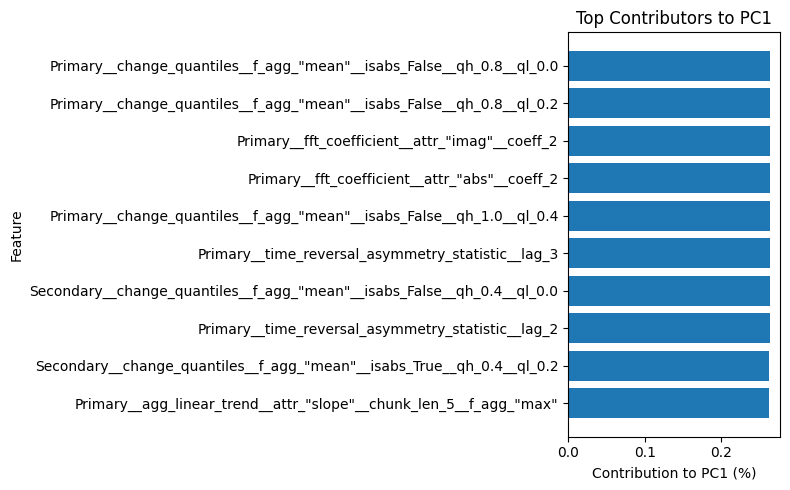

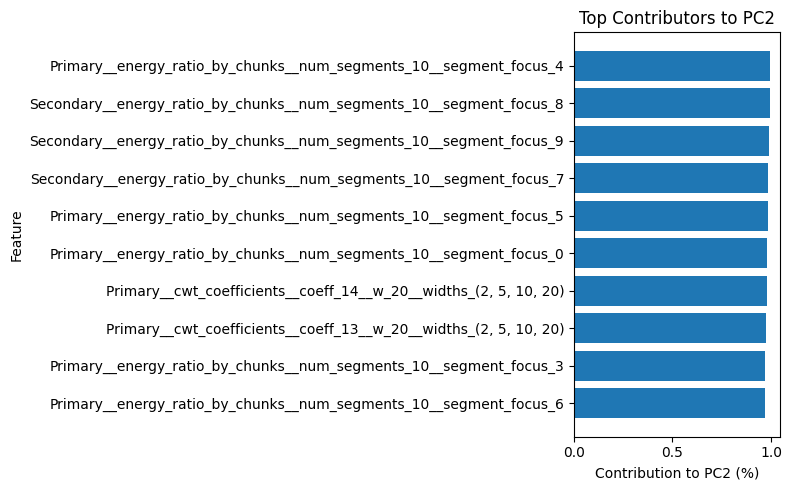

In [137]:
# loadings for all PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# percent contribution per feature per PC
contributions = loadings.pow(2)

contributions = contributions.div(
    contributions.sum(axis=0),
    axis=1
) * 100

top_n = 10

pc1_contributors = (
    contributions["PC1"]
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc1_contributors.index[::-1],
    pc1_contributors.values[::-1]
)

plt.xlabel("Contribution to PC1 (%)")
plt.ylabel("Feature")
plt.title("Top Contributors to PC1")
plt.tight_layout()
plt.show()

pc2_contributors = (
    contributions["PC2"]
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc2_contributors.index[::-1],
    pc2_contributors.values[::-1]
)

plt.xlabel("Contribution to PC2 (%)")
plt.ylabel("Feature")
plt.title("Top Contributors to PC2")
plt.tight_layout()
plt.show()

### Cumulative Variance Explained

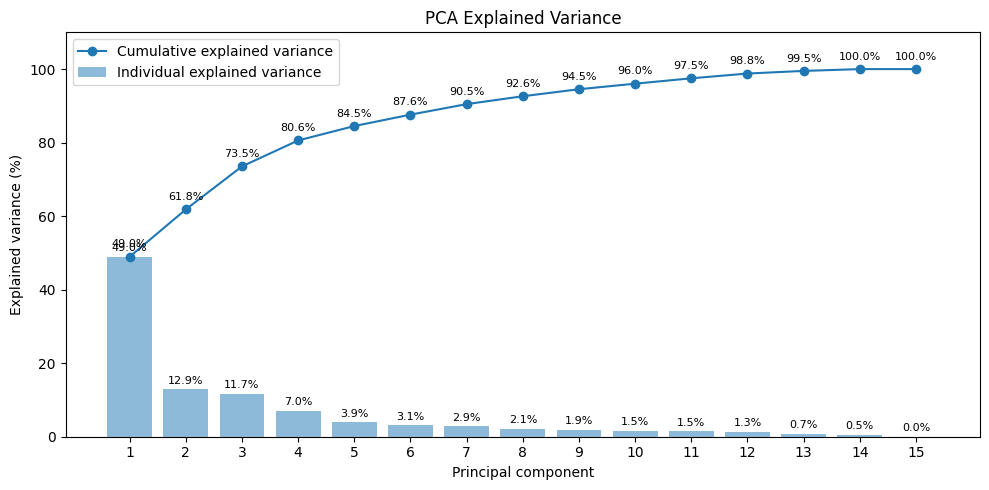

In [138]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

## Reservoir Computing

In [181]:
rc_data = data[data["filter_data"]].copy()
rc_data = rc_data.sort_values(["Sample", "Trial", "Time_new"])

length_check = (
    rc_data
    .groupby(["Sample", "Trial"])
    .size()
    .reset_index(name="n_points")
)

min_len = length_check["n_points"].min()

X_list = []
y_list = []

for (sample, trial), subset in rc_data.groupby(["Sample", "Trial"]):

    subset = subset.sort_values("Time_new").head(min_len)

    sequence = subset[[
        "Primary_shifted",
        "Secondary_shifted"
    ]].values

    X_list.append(sequence)
    y_list.append(sample)

X = X_list
y = np.array(y_list)

print(len(X))
print(X[0].shape)
print(y.shape)


le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)
print(y_encoded)

15
(50, 2)
(15,)
['aluminum' 'corkboard' 'glass' 'pdms' 'steel']
[0 0 0 1 1 1 2 2 2 3 3 3 4 4 4]


In [187]:
X_rc = []

for sequence in X:

    reservoir = Reservoir(
        units=50,
        sr=0.9,
        lr=0.3,
        input_scaling=0.5,
        seed=42
    )

    states = reservoir.run(sequence)

    features = np.concatenate([
        states.mean(axis=0),
        states.std(axis=0),
        states[-1, :]
    ])

    X_rc.append(features)

X_rc = np.array(X_rc)

print(X_rc.shape)

(15, 150)


### Principal Component Analysis

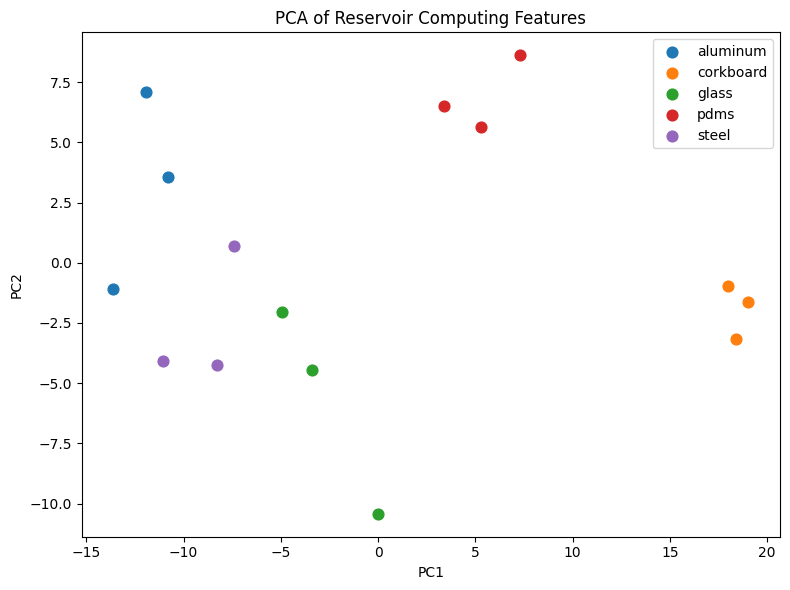

In [188]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rc)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

materials = np.unique(y)

plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Reservoir Computing Features")
plt.legend()
plt.tight_layout()
plt.show()

### Convex Hull Boundaries

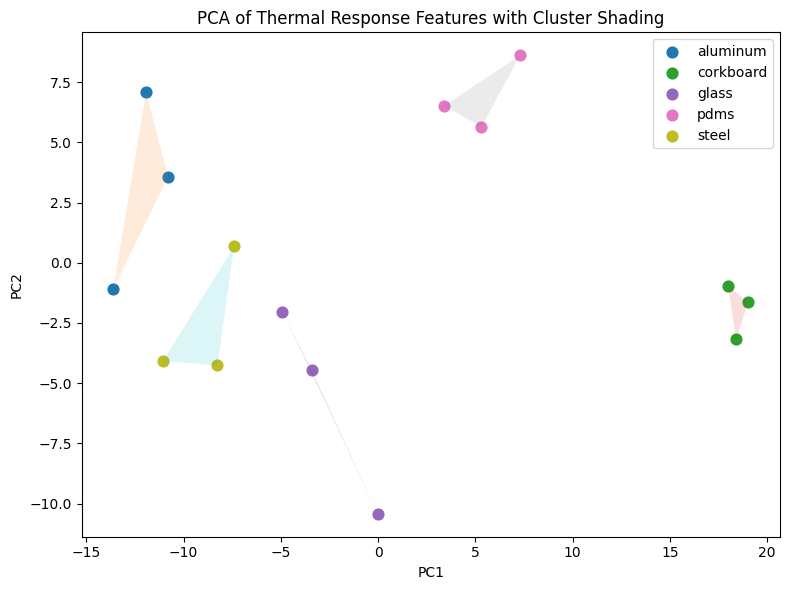

In [189]:
plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

    # shade cluster area
    if mask.sum() >= 3:
        points = X_pca[mask, :2]
        hull = ConvexHull(points)

        plt.fill(
            points[hull.vertices, 0],
            points[hull.vertices, 1],
            alpha=0.15
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features with Cluster Shading")
plt.legend()
plt.tight_layout()
plt.show()

### SVM Boundaries

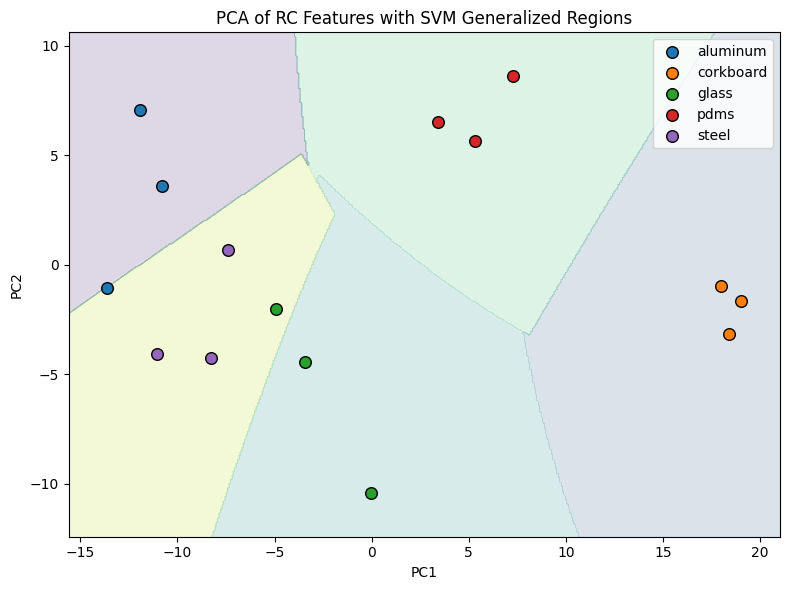

In [190]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

clf = SVC(
    kernel="rbf",
    C=0.5,
    gamma="scale"
)

clf.fit(X_pca[:, :2], y_encoded)

x_min, x_max = X_pca[:, 0].min() - 2, X_pca[:, 0].max() + 2
y_min, y_max = X_pca[:, 1].min() - 2, X_pca[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = clf.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.18,
    levels=np.arange(len(le.classes_) + 1) - 0.5
)

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=70,
        edgecolor="k"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of RC Features with SVM Generalized Regions")
plt.legend()
plt.tight_layout()
plt.show()

### Factor Loadings

150
150
(150, 15)


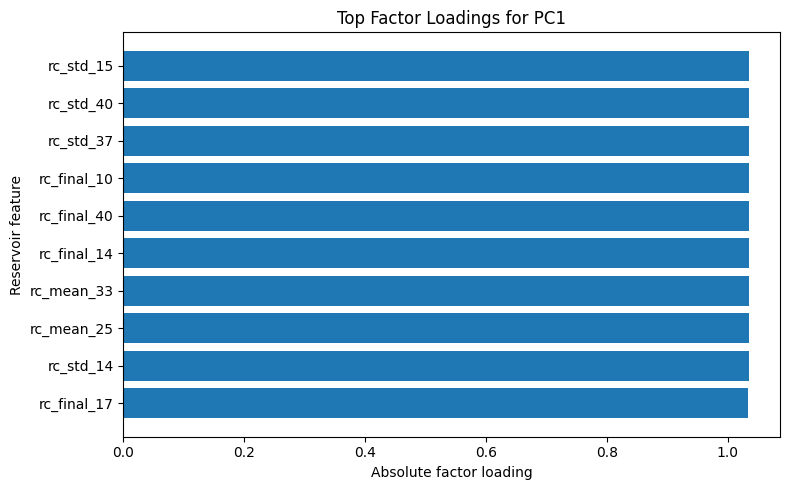

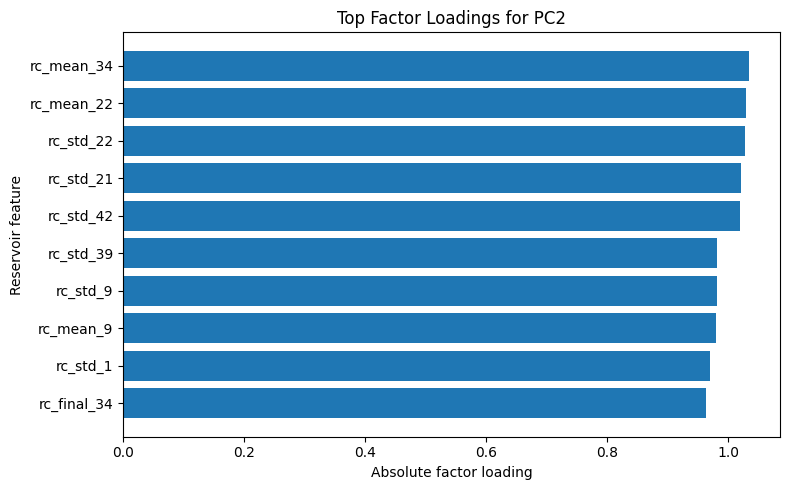

In [193]:
# infer reservoir feature names from X_rc
n_units = X_rc.shape[1] // 3

feature_cols = (
    [f"rc_mean_{i}" for i in range(n_units)] +
    [f"rc_std_{i}" for i in range(n_units)] +
    [f"rc_final_{i}" for i in range(n_units)]
)

# safety check
print(X_rc.shape[1])
print(len(feature_cols))
print(pca.components_.T.shape)

# factor loadings
factor_loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

top_n = 10

pc1_factor_loadings = (
    factor_loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc1_factor_loadings.index[::-1],
    pc1_factor_loadings.values[::-1]
)

plt.xlabel("Absolute factor loading")
plt.ylabel("Reservoir feature")
plt.title("Top Factor Loadings for PC1")
plt.tight_layout()
plt.show()


pc2_factor_loadings = (
    factor_loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(top_n)
)

plt.figure(figsize=(8, 5))

plt.barh(
    pc2_factor_loadings.index[::-1],
    pc2_factor_loadings.values[::-1]
)

plt.xlabel("Absolute factor loading")
plt.ylabel("Reservoir feature")
plt.title("Top Factor Loadings for PC2")
plt.tight_layout()
plt.show()

### Cumulative Variance Explained

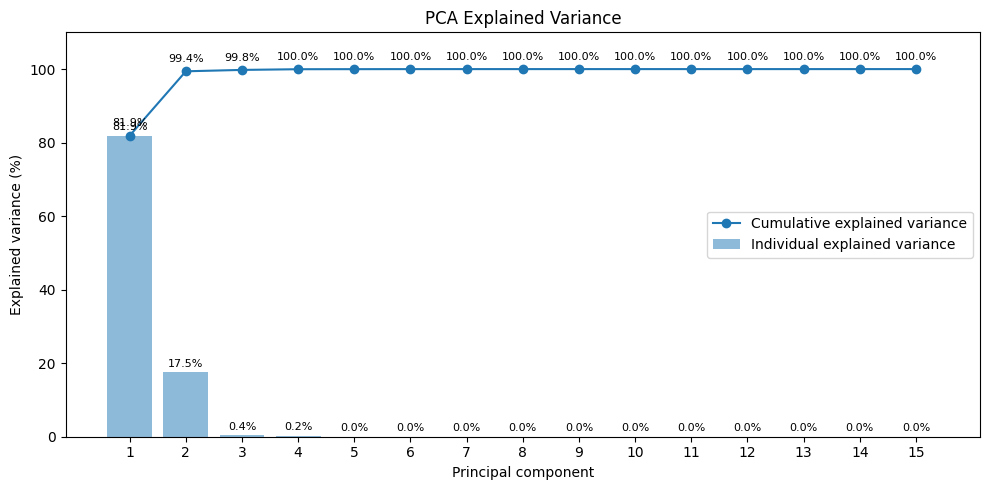

In [194]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()